# <center> Assignment 2 </center>

**File name: assignment_2.ipynb**<br>
**Date:** 16-05-2025<br>

This notebook is a submission file of student_24113346 as a requirement for unit CITS5508.

The notebook contains:

[Introduction](#introduction)
1. [Voting Classifier](#part_1)
    - 1.1. [Methodology](#methodology_1)
    - 1.2. [Implementation](#implementation_1)
        - 1.2.1. [Import Libraries](#import_1)  
        - 1.2.2. [Import Data](#import_data_1)
        - 1.2.3. [Exploratory Analysis](#eda_1)
        - 1.2.4. [Data Preprocessing](#preprocessing_1)
        - 1.2.5. [Model Fitting](#modelfitting_1)
          - 1.2.5.1. [Logistic Regression](#logreg_1)
          - 1.2.5.2. [Random Forest](#randomforest_1)
          - 1.2.5.3. [Support Vector Machine](#svc_1)
          - 1.2.5.4. [Voting Classifier](#votingclassifier_1)
    - 1.3. [Result](#result_1)
2. [Labeled Faces in the Wild](#part_2)
    - 2.1. [Methodology](#methodology_2)
    - 2.2. [Implementation](#Implementation_2)
        - 2.2.1. [Import Libraries](#import_2)
        - 2.2.2. [Import Data](#import_data_2)
        - 2.2.3. [Exploratory Analysis](#eda_2)
        - 2.2.4. [Feature Importance Analysis](#preprocessing_2)
        - 2.2.5. [Principal Component Analysis (PCA)](#pca)
        - 2.2.6. [Random Forest PCA-integrated](#randomforest_pca)
    - 2.3. [Result](#result_2)

[Conclusion](#conclusion)

In [56]:
# Install any package not already installed
import sys
import subprocess

# List of required packages
required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "sklearn"
]


for package in required_packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

## Introduction
<a id=introduction></a>

With the rapid advancement of Artificial Intelligence (AI) technologies, particularly the rise of conversational tools like ChatGPT and Gemini, public and professional interest in the fields of AI and Machine Learning (ML) has surged. ML has shown immense potential across a wide spectrum of disciplines, ranging from healthcare and finance to marketing and environmental science. One of the most impactful applications of ML lies in classification problems, where the goal is to accurately categorize data into predefined groups. In this report, we explore two distinct ML approaches to address such problems effectively.

The first approach focuses on ensemble learning, a powerful technique that combines the predictions of multiple individual models to produce a more robust and accurate classifier. By integrating several algorithms—such as logistic regression, decision trees, and support vector machines—into a unified framework like a voting classifier, ensemble methods aim to enhance predictive performance and minimize model bias and variance.

The second approach involves dimensionality reduction, which addresses the challenges posed by high-dimensional datasets. By reducing the number of input features while preserving as much relevant information as possible, this technique simplifies the model, improves interpretability, and can even enhance classification accuracy. This report demonstrates both approaches and compares their effectiveness in a real-world healthcare dataset.

## 1. Voting Classifier
<a id=part_1></a>

In this section, we apply Voting Classifier (VC) in identifying breast cancer patient from the breast mass feature input. The idea underlying ensemble solution is the concept of *wisdom of the crowd*. By aggregating the predictions of multiple algorithms, the ensemble model will produce a final prediction.
In order to compare the performance of the individuals and aggregated model, we use the breast cancer problem obtained from [Breast Cancer Wincosin (Diagnostic)](https://doi.org/10.24432/C5DW2B) dataset.

### 1.1. Methodology:

VC is an ensemble method, where the final model is trained with the prediction from inputting model and aggregates their result to make final the prediction. Although the VC has 2 strategies: hard-voting and soft-voting, we will only implement, specifically, soft-voting in this report. Soft-voting is the strategy where the final prediction is made from aggregated average of the classifiers.

To train the VC, we will feed the model with the 3 algorithms trained with the breast cancer dataset:
- Logistic Regression: a supervised algorithm commonly used for binary classification tasks. It models the probability that a given input belongs to a particular class using a logistic function. The algorithm estimates the best-fitting parameters to sperate classes by finding a decision boundary, typically a linear one, that minimises the classification error through maximum likelihood estimation.
- Support Vector Machine (SVC): a supervised algorithm that can be used for both classification and regression tasks. The idea behind is to find the hyperplane that best separates the classes in feature space. The algorithm aims to maximise margin between classes while minimising the classification errors.
- Random Forest: also an ensemble learning algorithm can be used for classification task. The forest is built upon multiple decision trees during the training and combines their outputs to improve accuracy while controls overfitting.

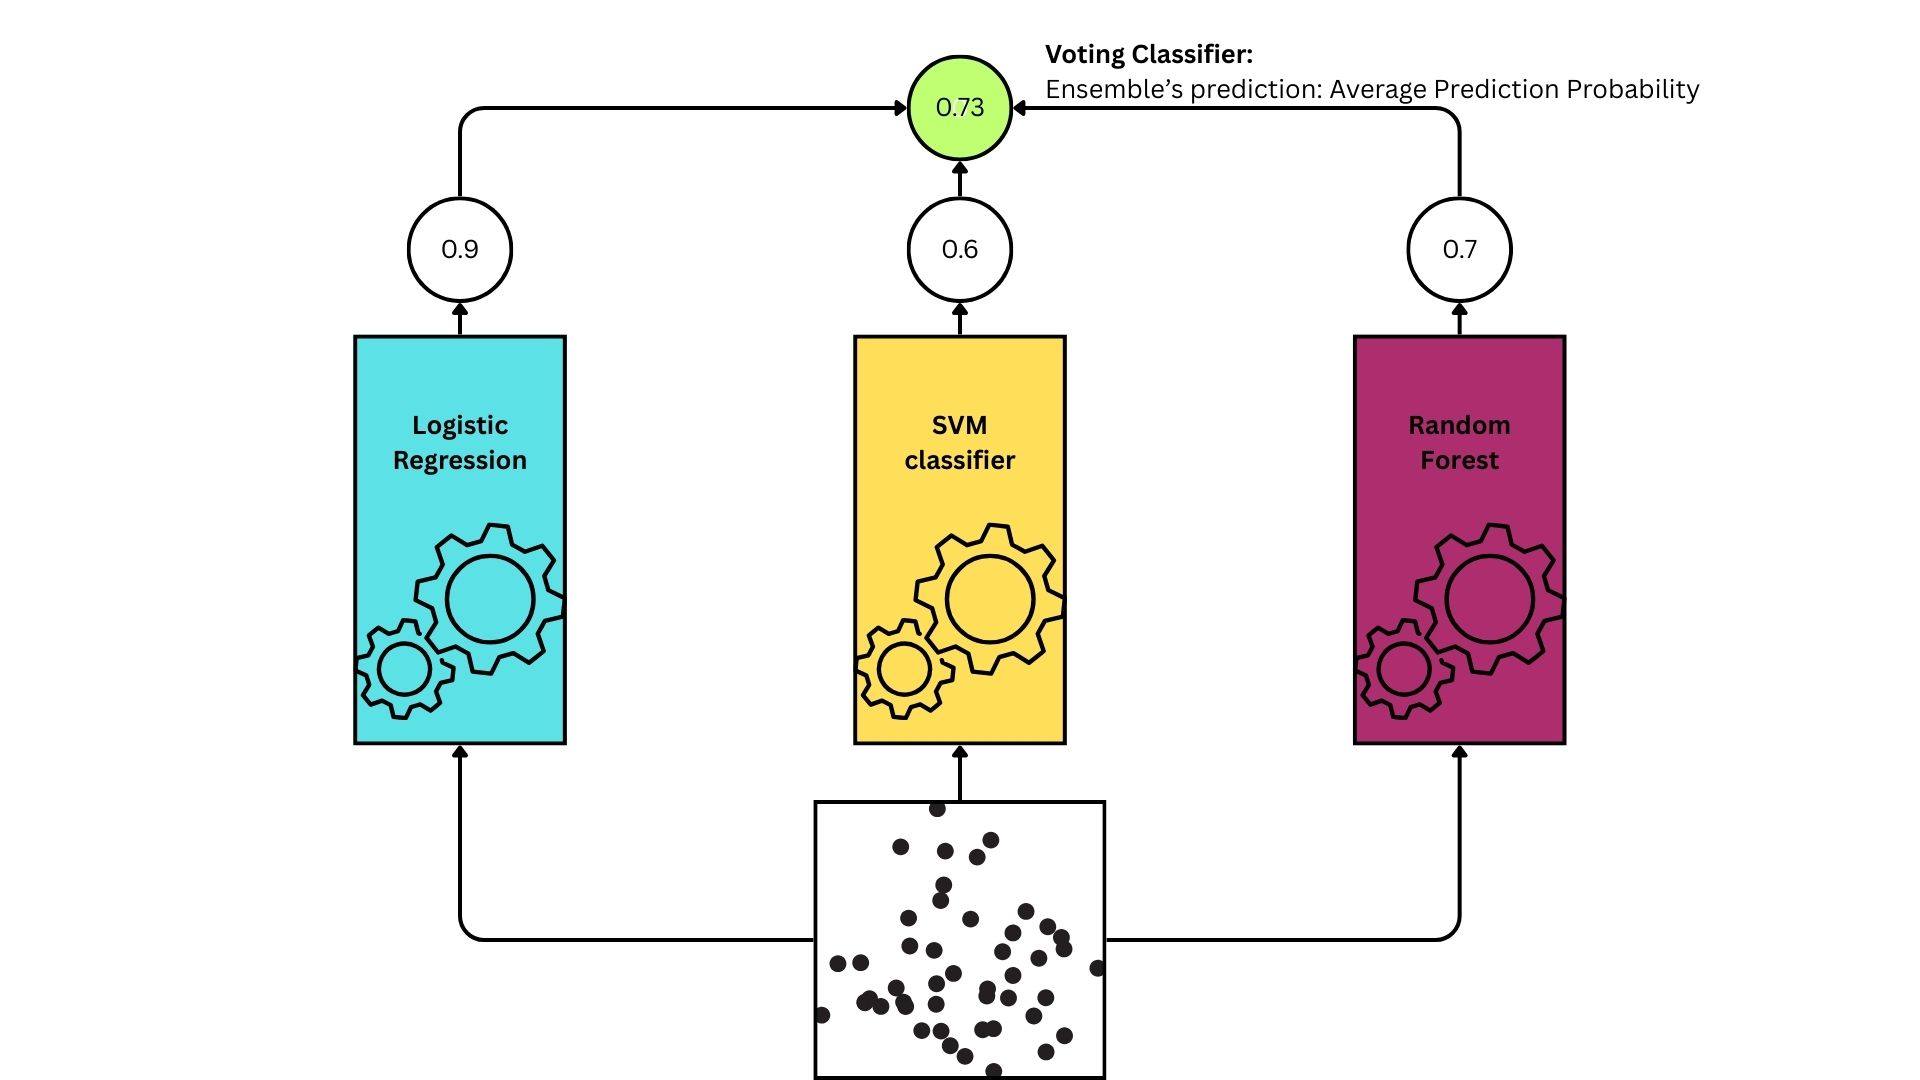

#### 1.2.1. Import Libraries
<a id=import_1></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, recall_score, precision_score, f1_score
from timeit import default_timer as timer

#### 1.2.2. Import Data
<a id=import_data_1></a>

In [58]:
col_names = [
    "ID",
    "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]
wdbc = pd.read_csv('wdbc.data', names=col_names)
wdbc

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


#### 1.2.3. Exploratory Data Analysis
<a id= eda_1>

In [59]:
wdbc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The data consists of 32 columns:
- The first 2 columns are:
    - ID
    - Diagnosis: Patient classification where B is benign and M is malignant
- The rest 3 columns are the features extracted from the breast mass where the first 10 are the mean, the next 10 are standard error, and the last 10 are the average of 3 worst cases:
    - radius: mean of distances from center to points on the perimeter
    - texture: standard deviation of gray-scale values
    - permiter
    - area
    - smoothness:local variation in radius lengths
    - compactness: perimeter^2 / area - 1.0
    - concavity: severity of concave portions of the contour
    - concave points: number of concave portions of the contour
    - symmetry
    - fractal dimension: "coastline approximation" - 1

In [60]:
wdbc.describe()

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Since ID column does not have any implication, we will drop it

In [61]:
wdbc = wdbc.drop(columns='ID', errors='ignore') #Drop the ID column

In [62]:
wdbc.isna().sum() #Checking missing value

,0
Diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0
symmetry_mean,0


There are no missing values recorded

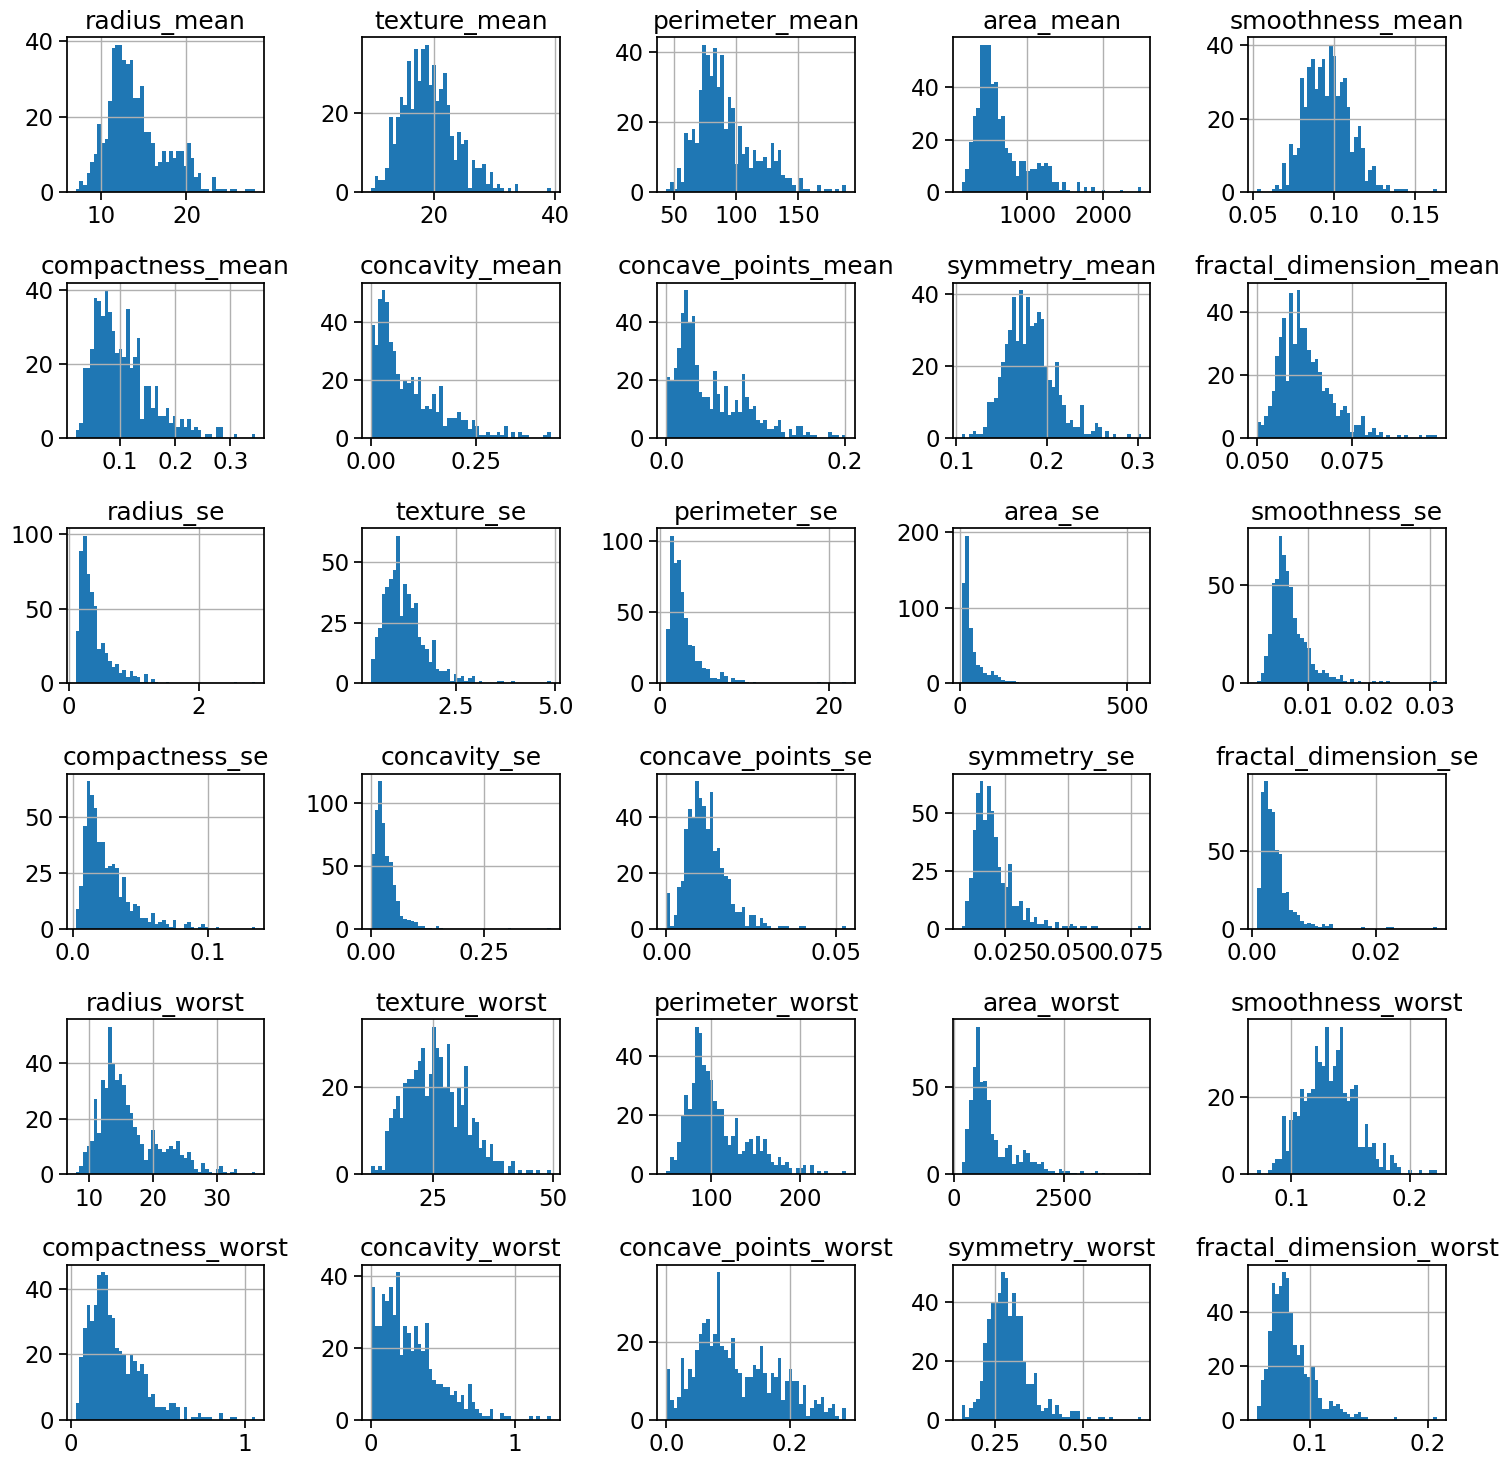

In [63]:
#Histograms for all features
wdbc.hist(bins=50, figsize=(15, 15))
plt.tight_layout()
plt.show()

In [64]:
#Seperate columns into sets for better visualisation
mean_columns = wdbc.columns[wdbc.columns.str.contains('mean')]
se_columns = wdbc.columns[wdbc.columns.str.contains('se')]
worst_columns = wdbc.columns[wdbc.columns.str.contains('worst')]

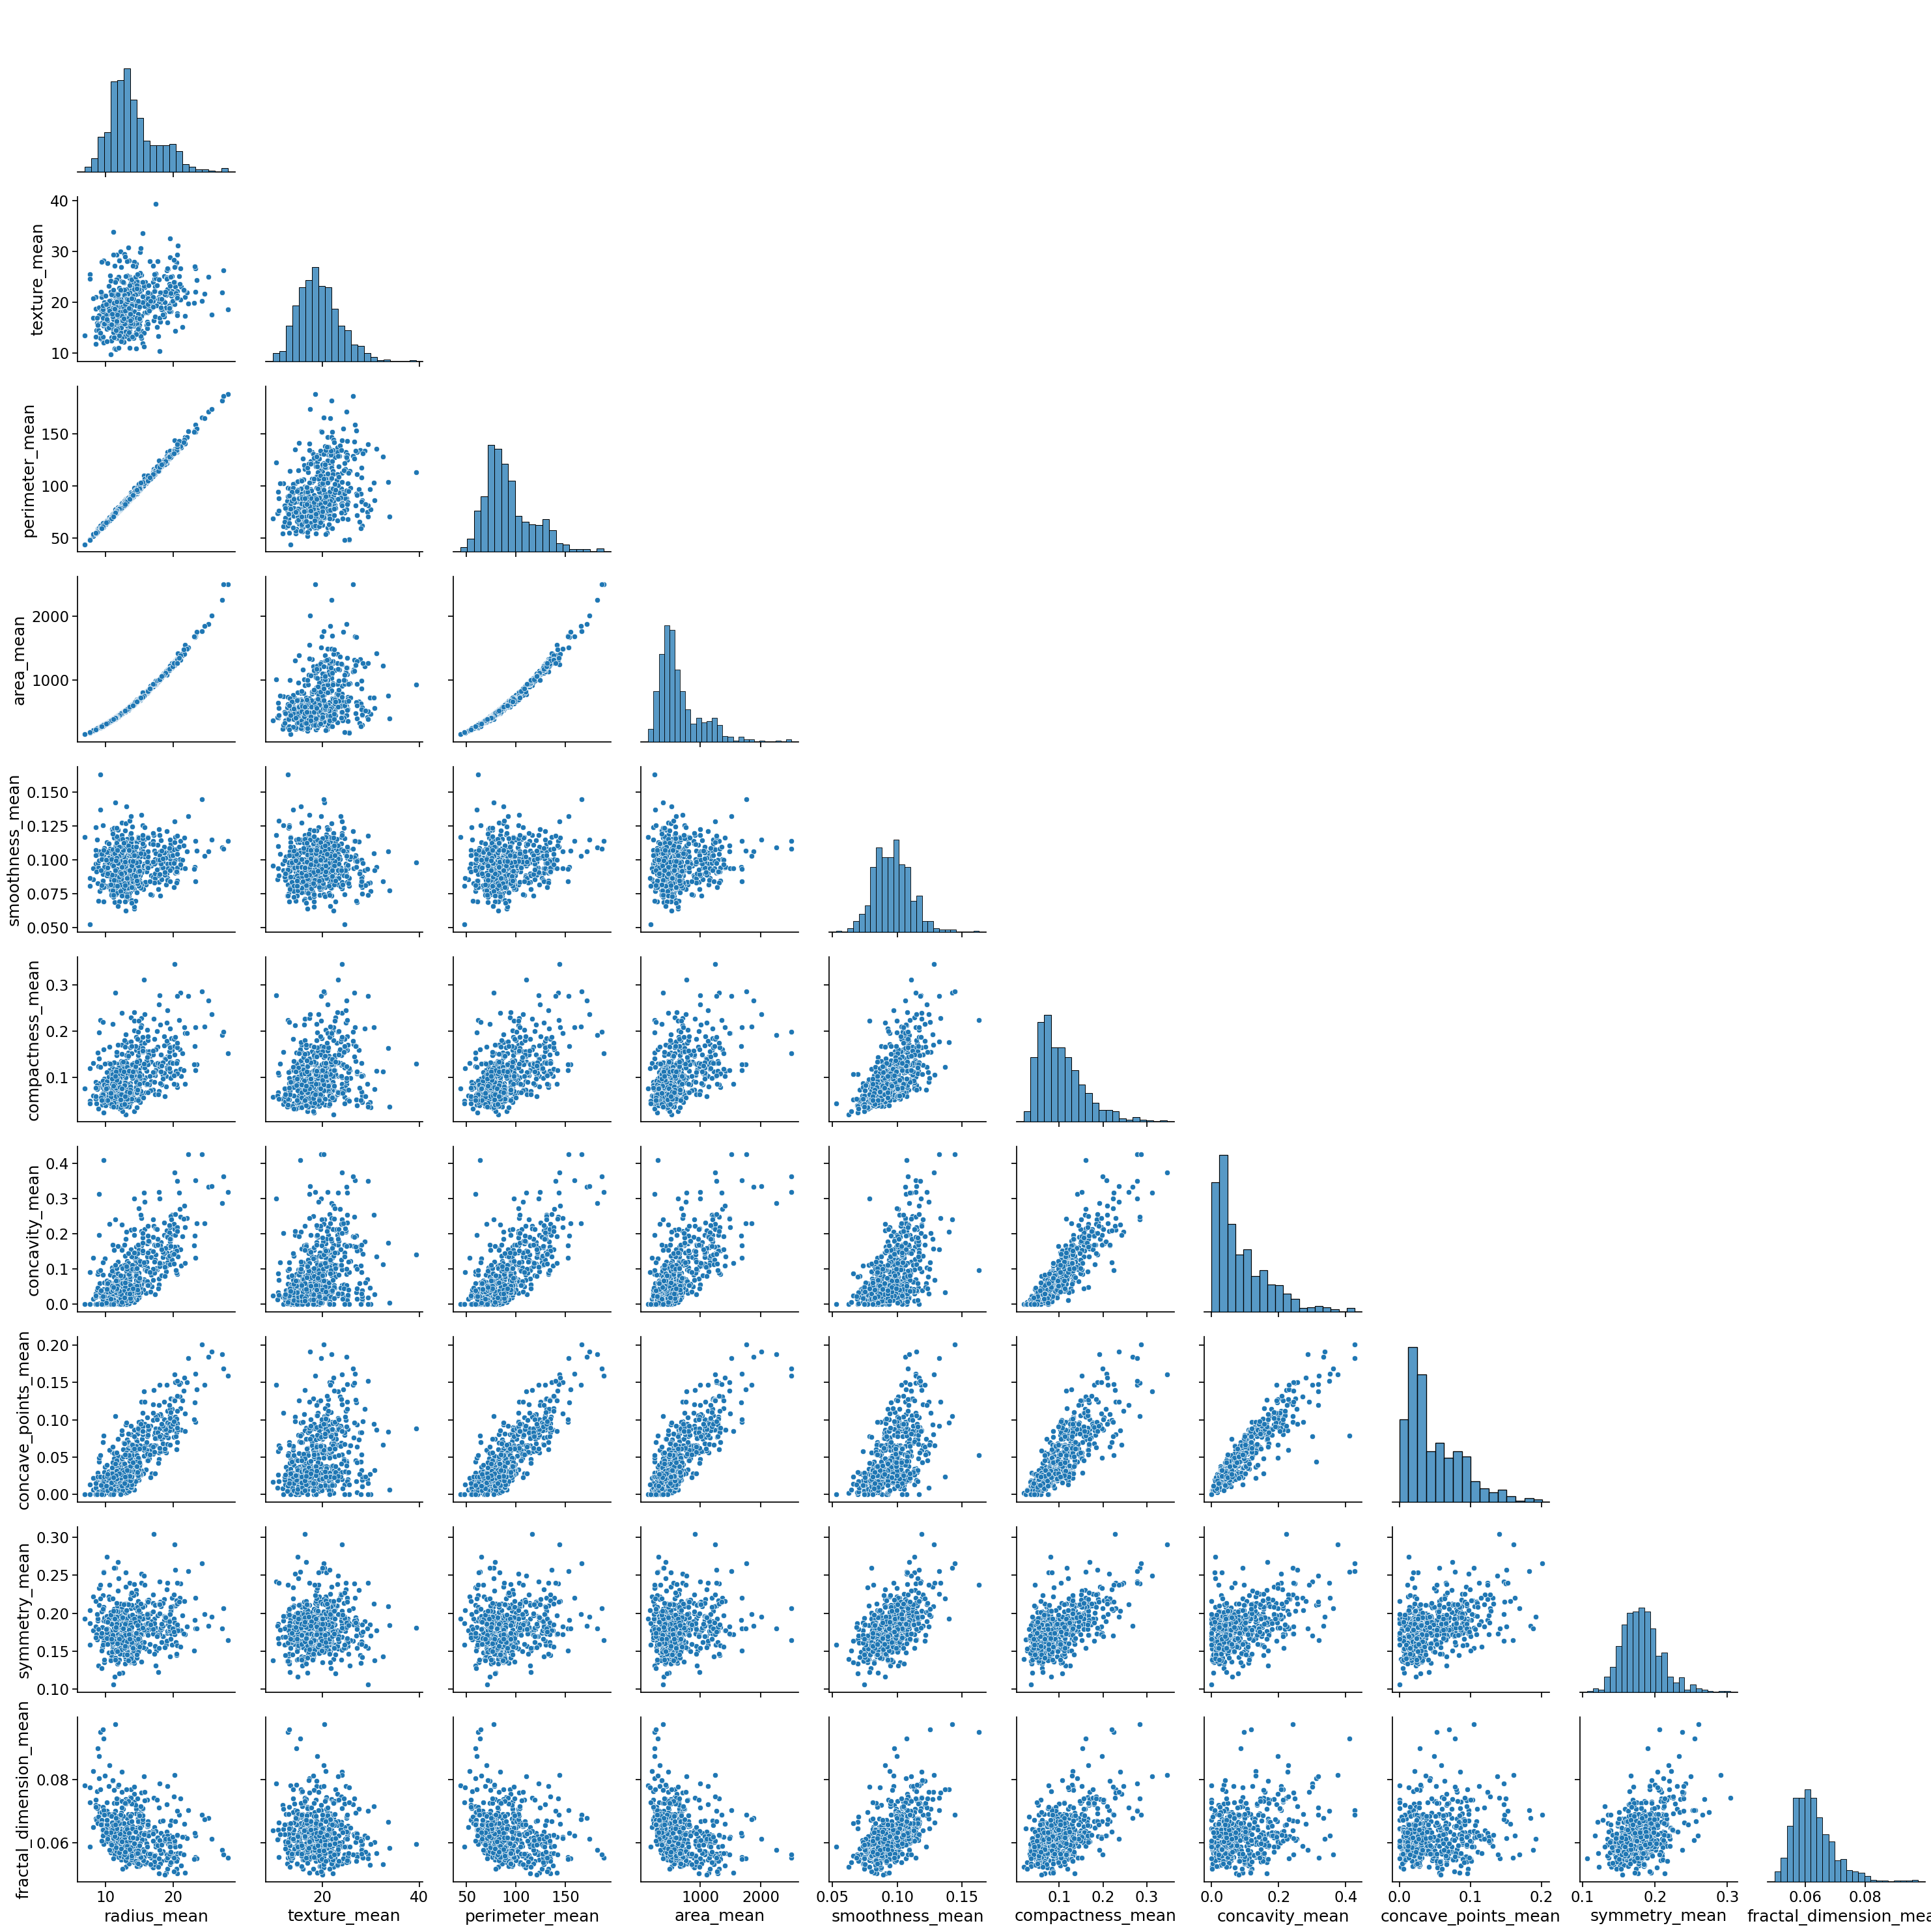

In [65]:
#Histogram and Scatter Plot for mean features
sns.set_context("notebook", font_scale=1.5)
axes = sns.pairplot(wdbc, vars= mean_columns, corner=True, height=3, aspect=1)
plt.tight_layout()
plt.show()

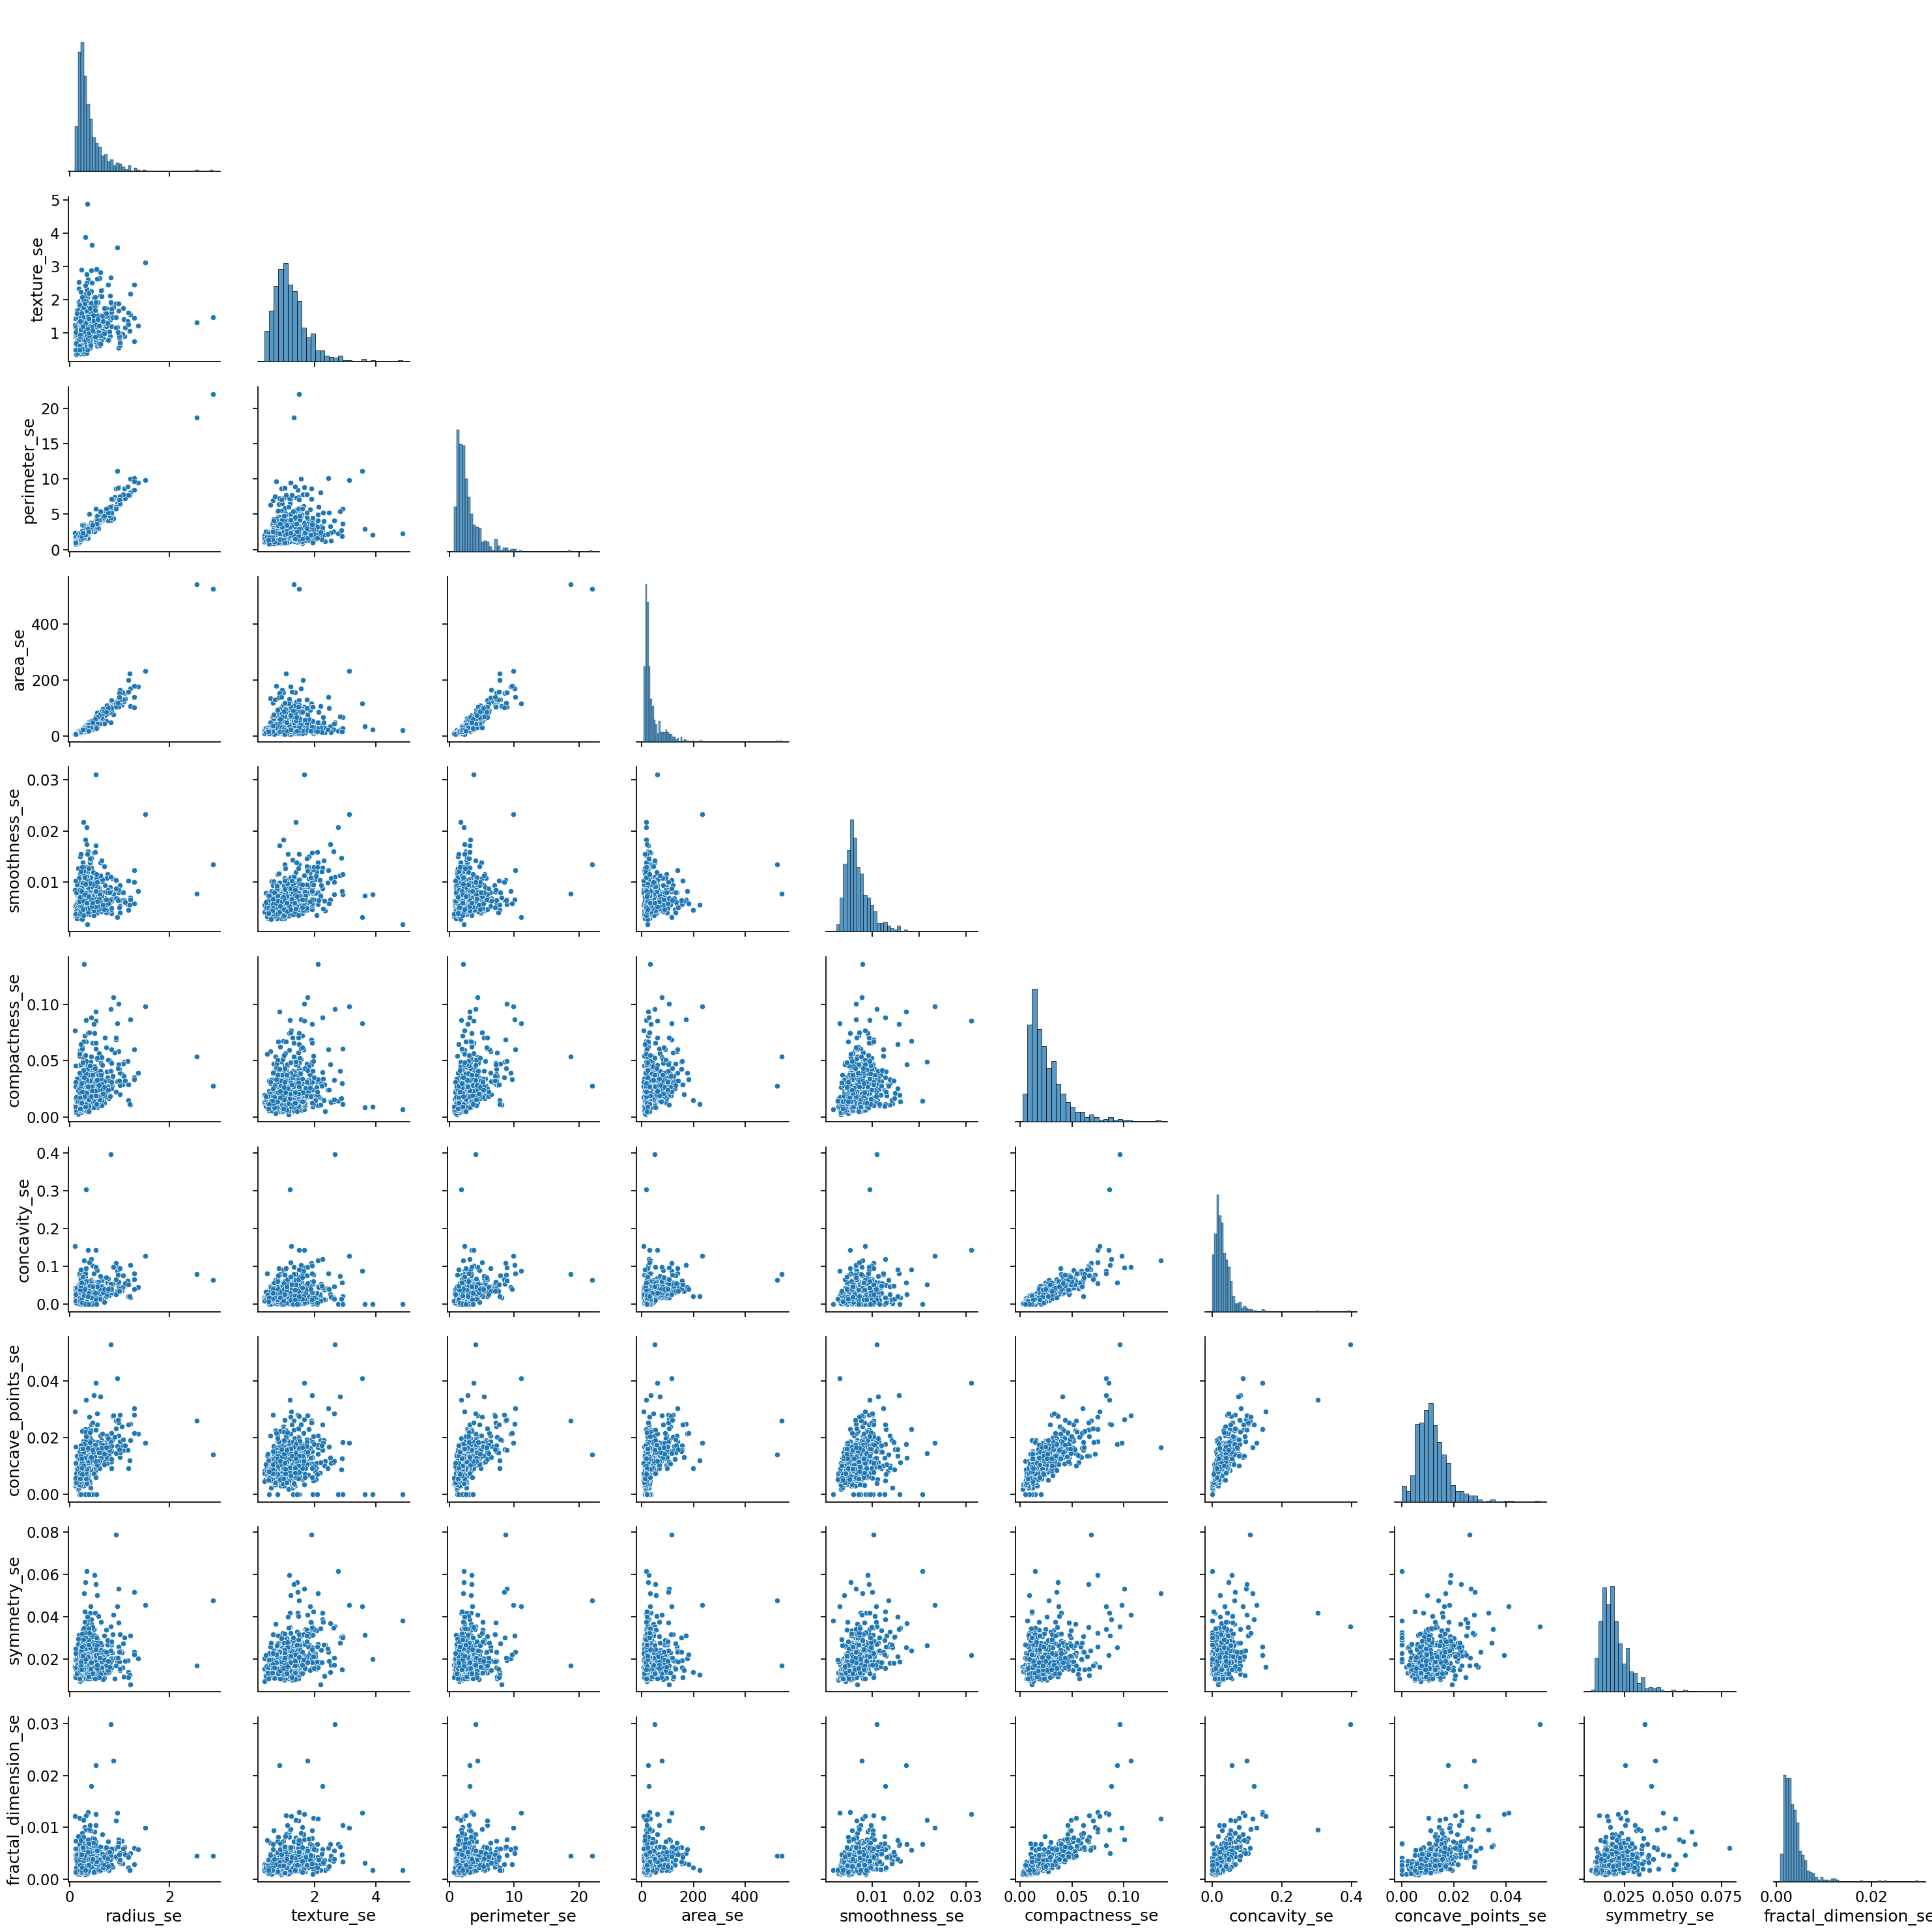

In [66]:
#Histogram and Scatter Plot for standard error features
sns.set_context("notebook", font_scale=1.5)
axes = sns.pairplot(wdbc, vars= se_columns, corner=True, height=3, aspect=1)
plt.tight_layout()
plt.show()

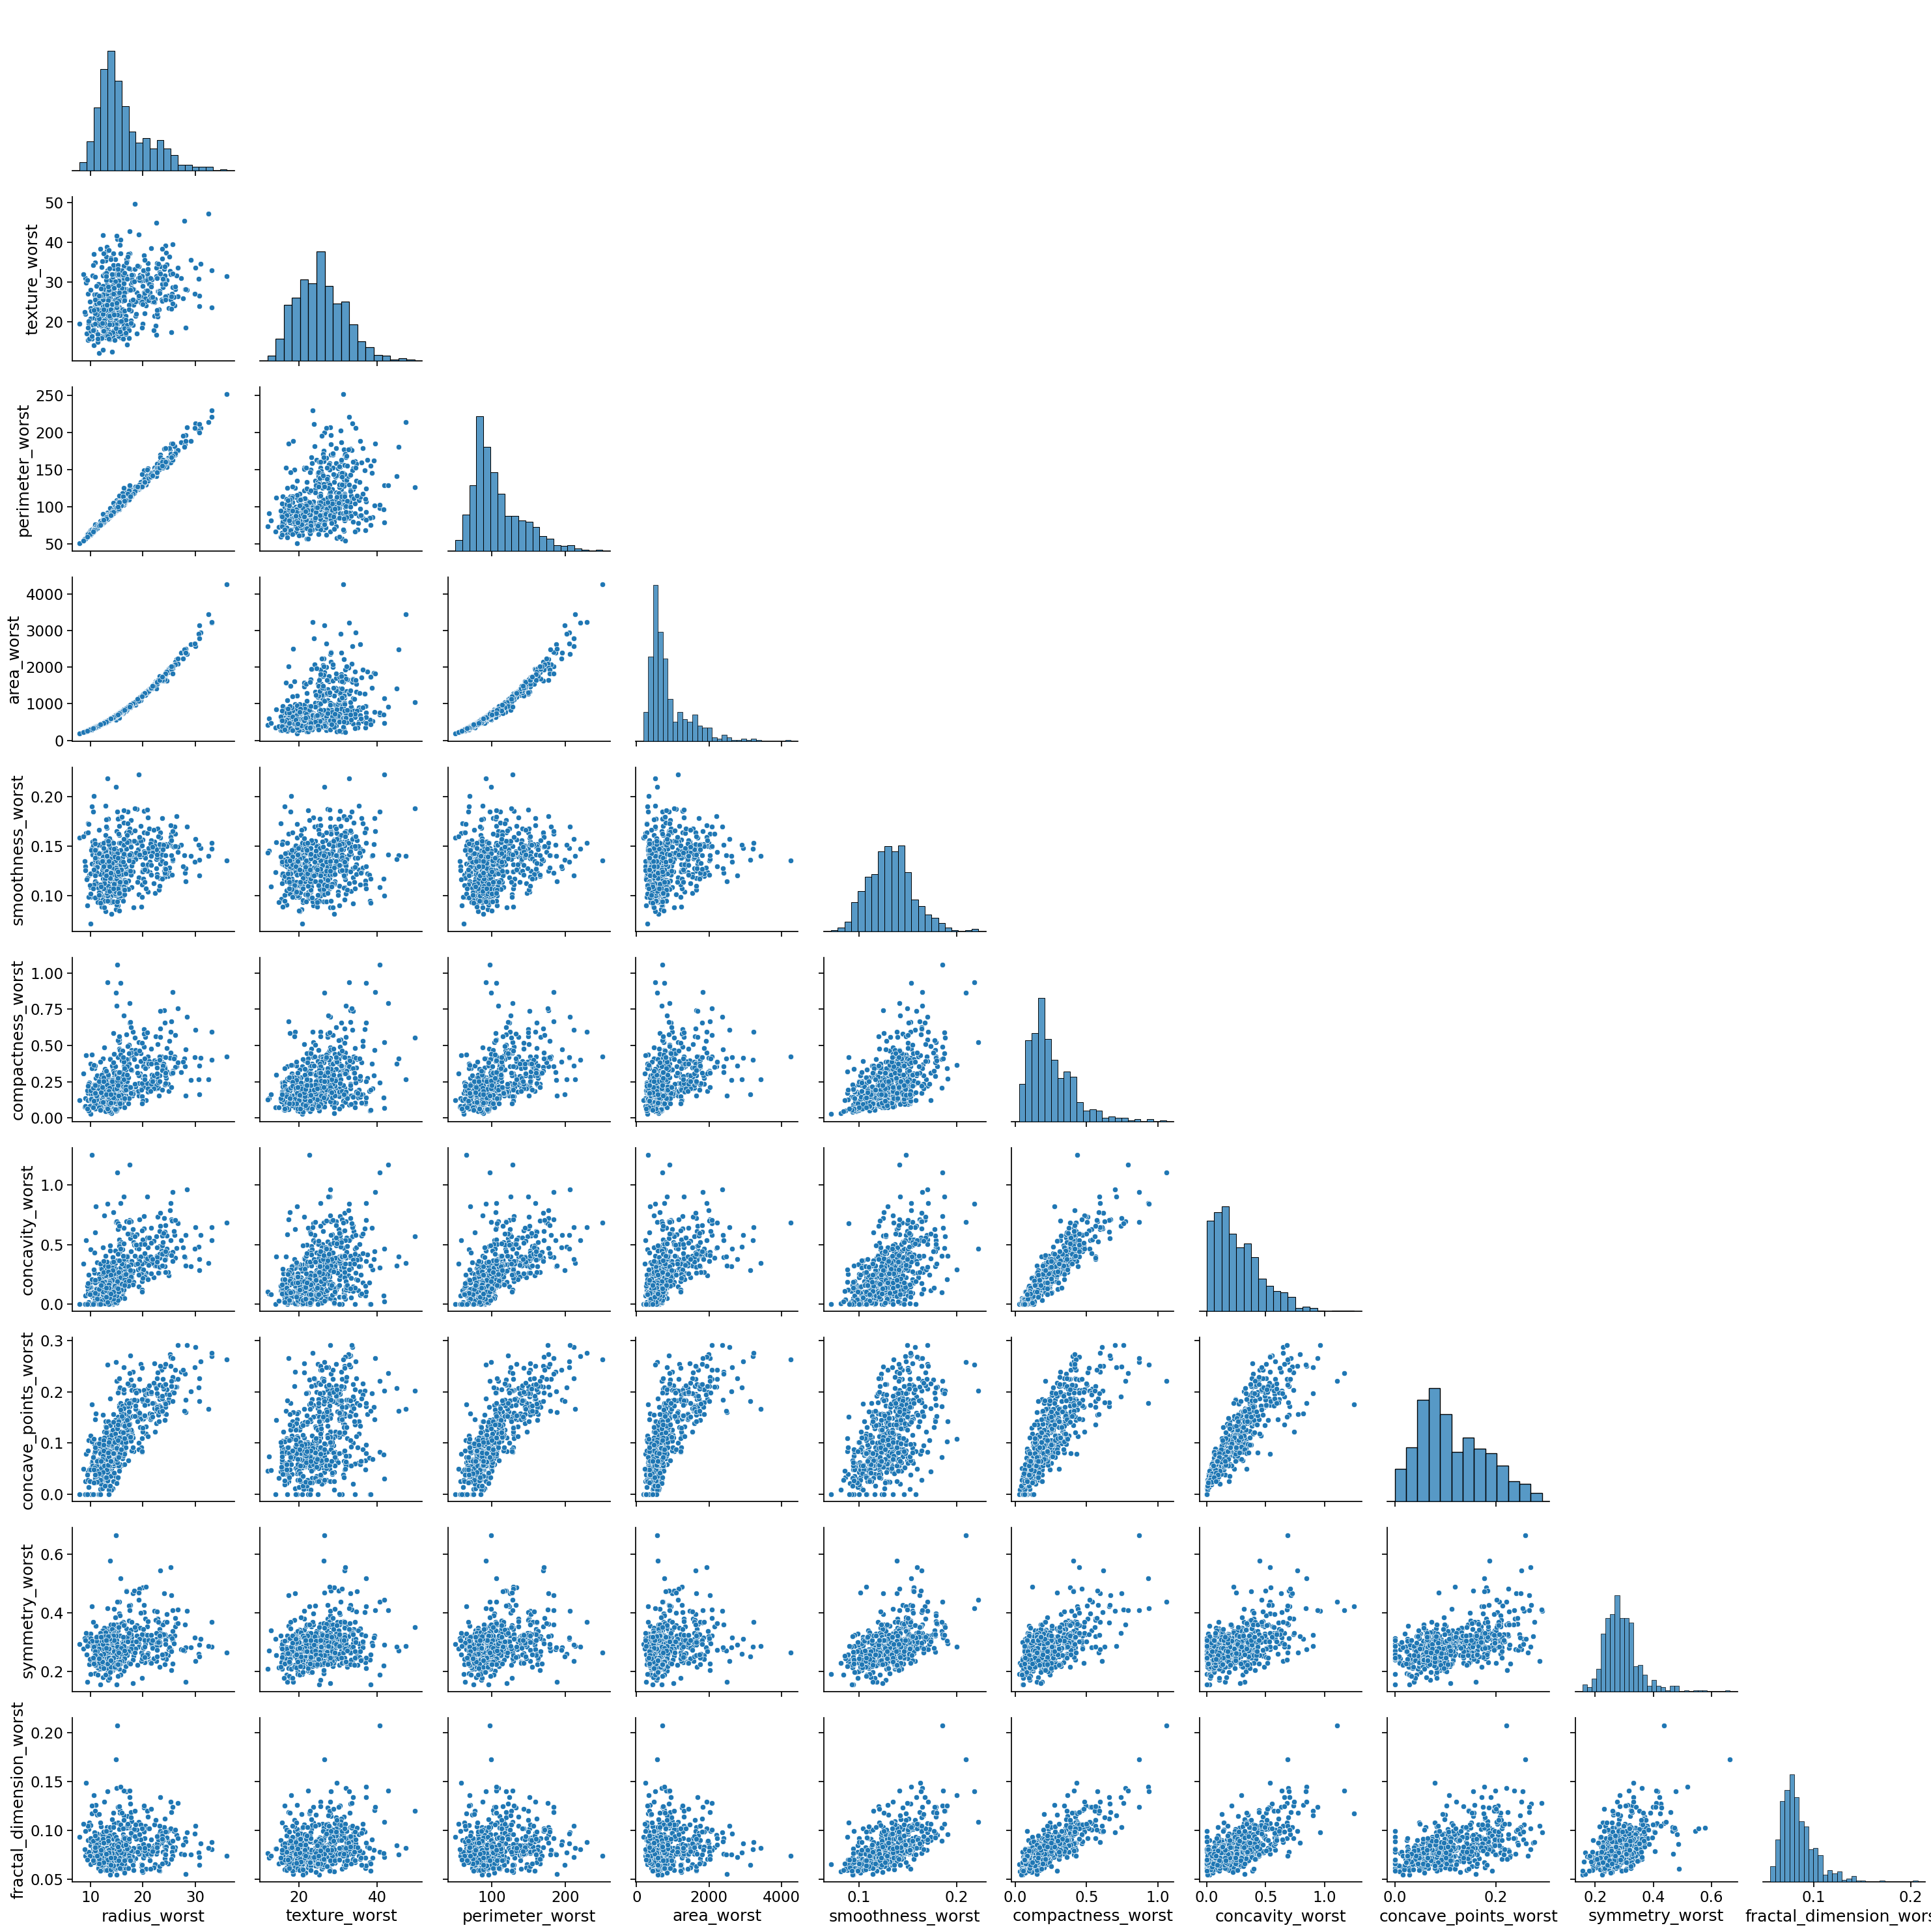

In [67]:
#Histogram and Scatter Plot for worst features
sns.set_context("notebook", font_scale=1.5)
axes = sns.pairplot(wdbc, vars= worst_columns, corner=True, height=3, aspect=1)
plt.tight_layout()
plt.show()

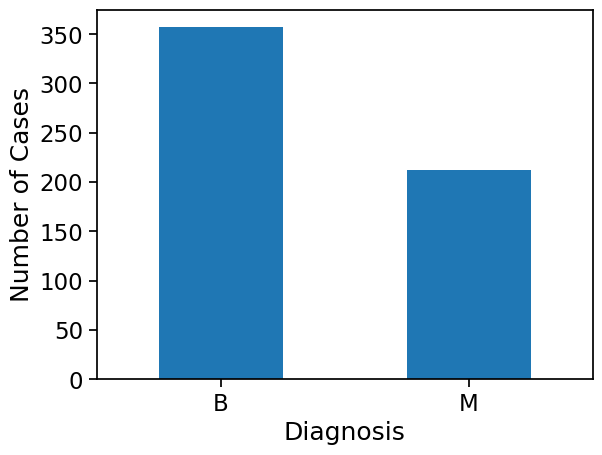

In [68]:
wdbc['Diagnosis'].value_counts().sort_index().plot.bar()
plt.tick_params(axis='x', labelrotation=0)
plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')
plt.show()

The labels are not equally distributed

In [69]:
wdbc['Diagnosis'].value_counts(normalize=True)

,proportion
Diagnosis,
B,0.627417
M,0.372583


Data is unbalanced, there are more benign cases than Malignant => Should stratify sampling

In [70]:
#Create list of feature columns & Target column
feature_cols = wdbc.columns.drop('Diagnosis')
target_col = 'Diagnosis'

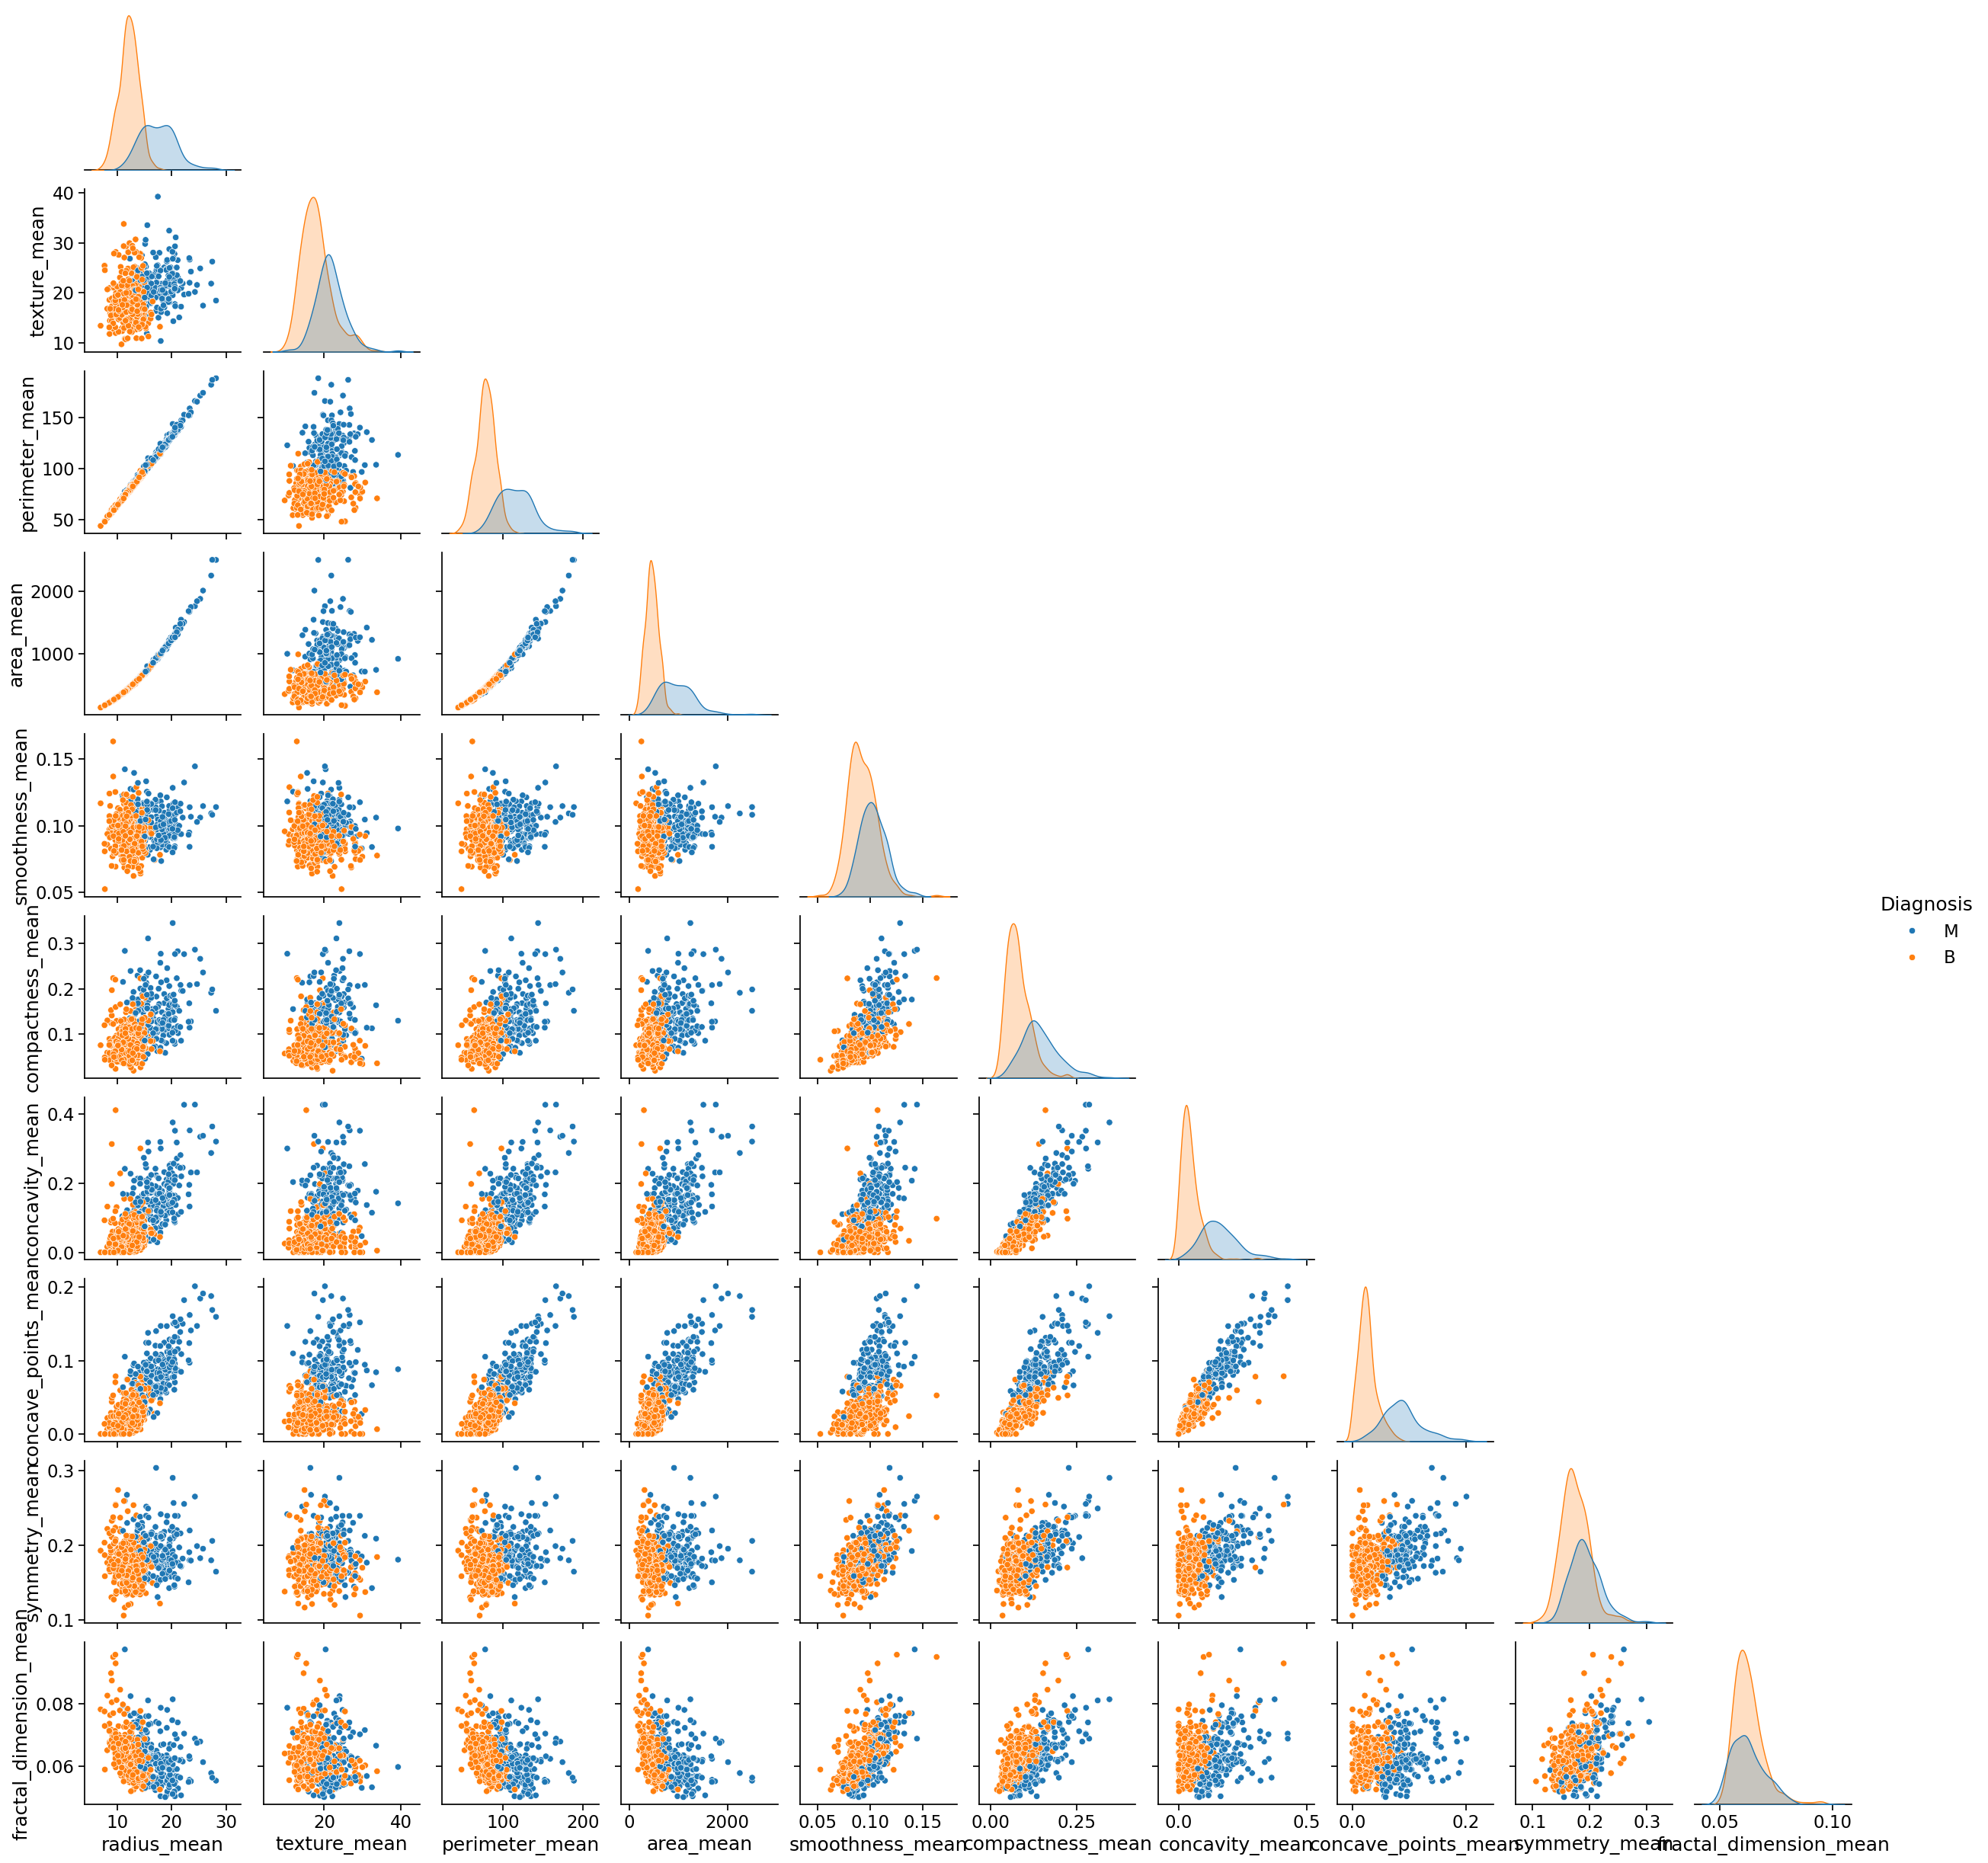

In [71]:
# Density and scatter plot by Label of Mean features
sns.pairplot(wdbc, hue = 'Diagnosis', vars = mean_columns, corner=True)
plt.show()

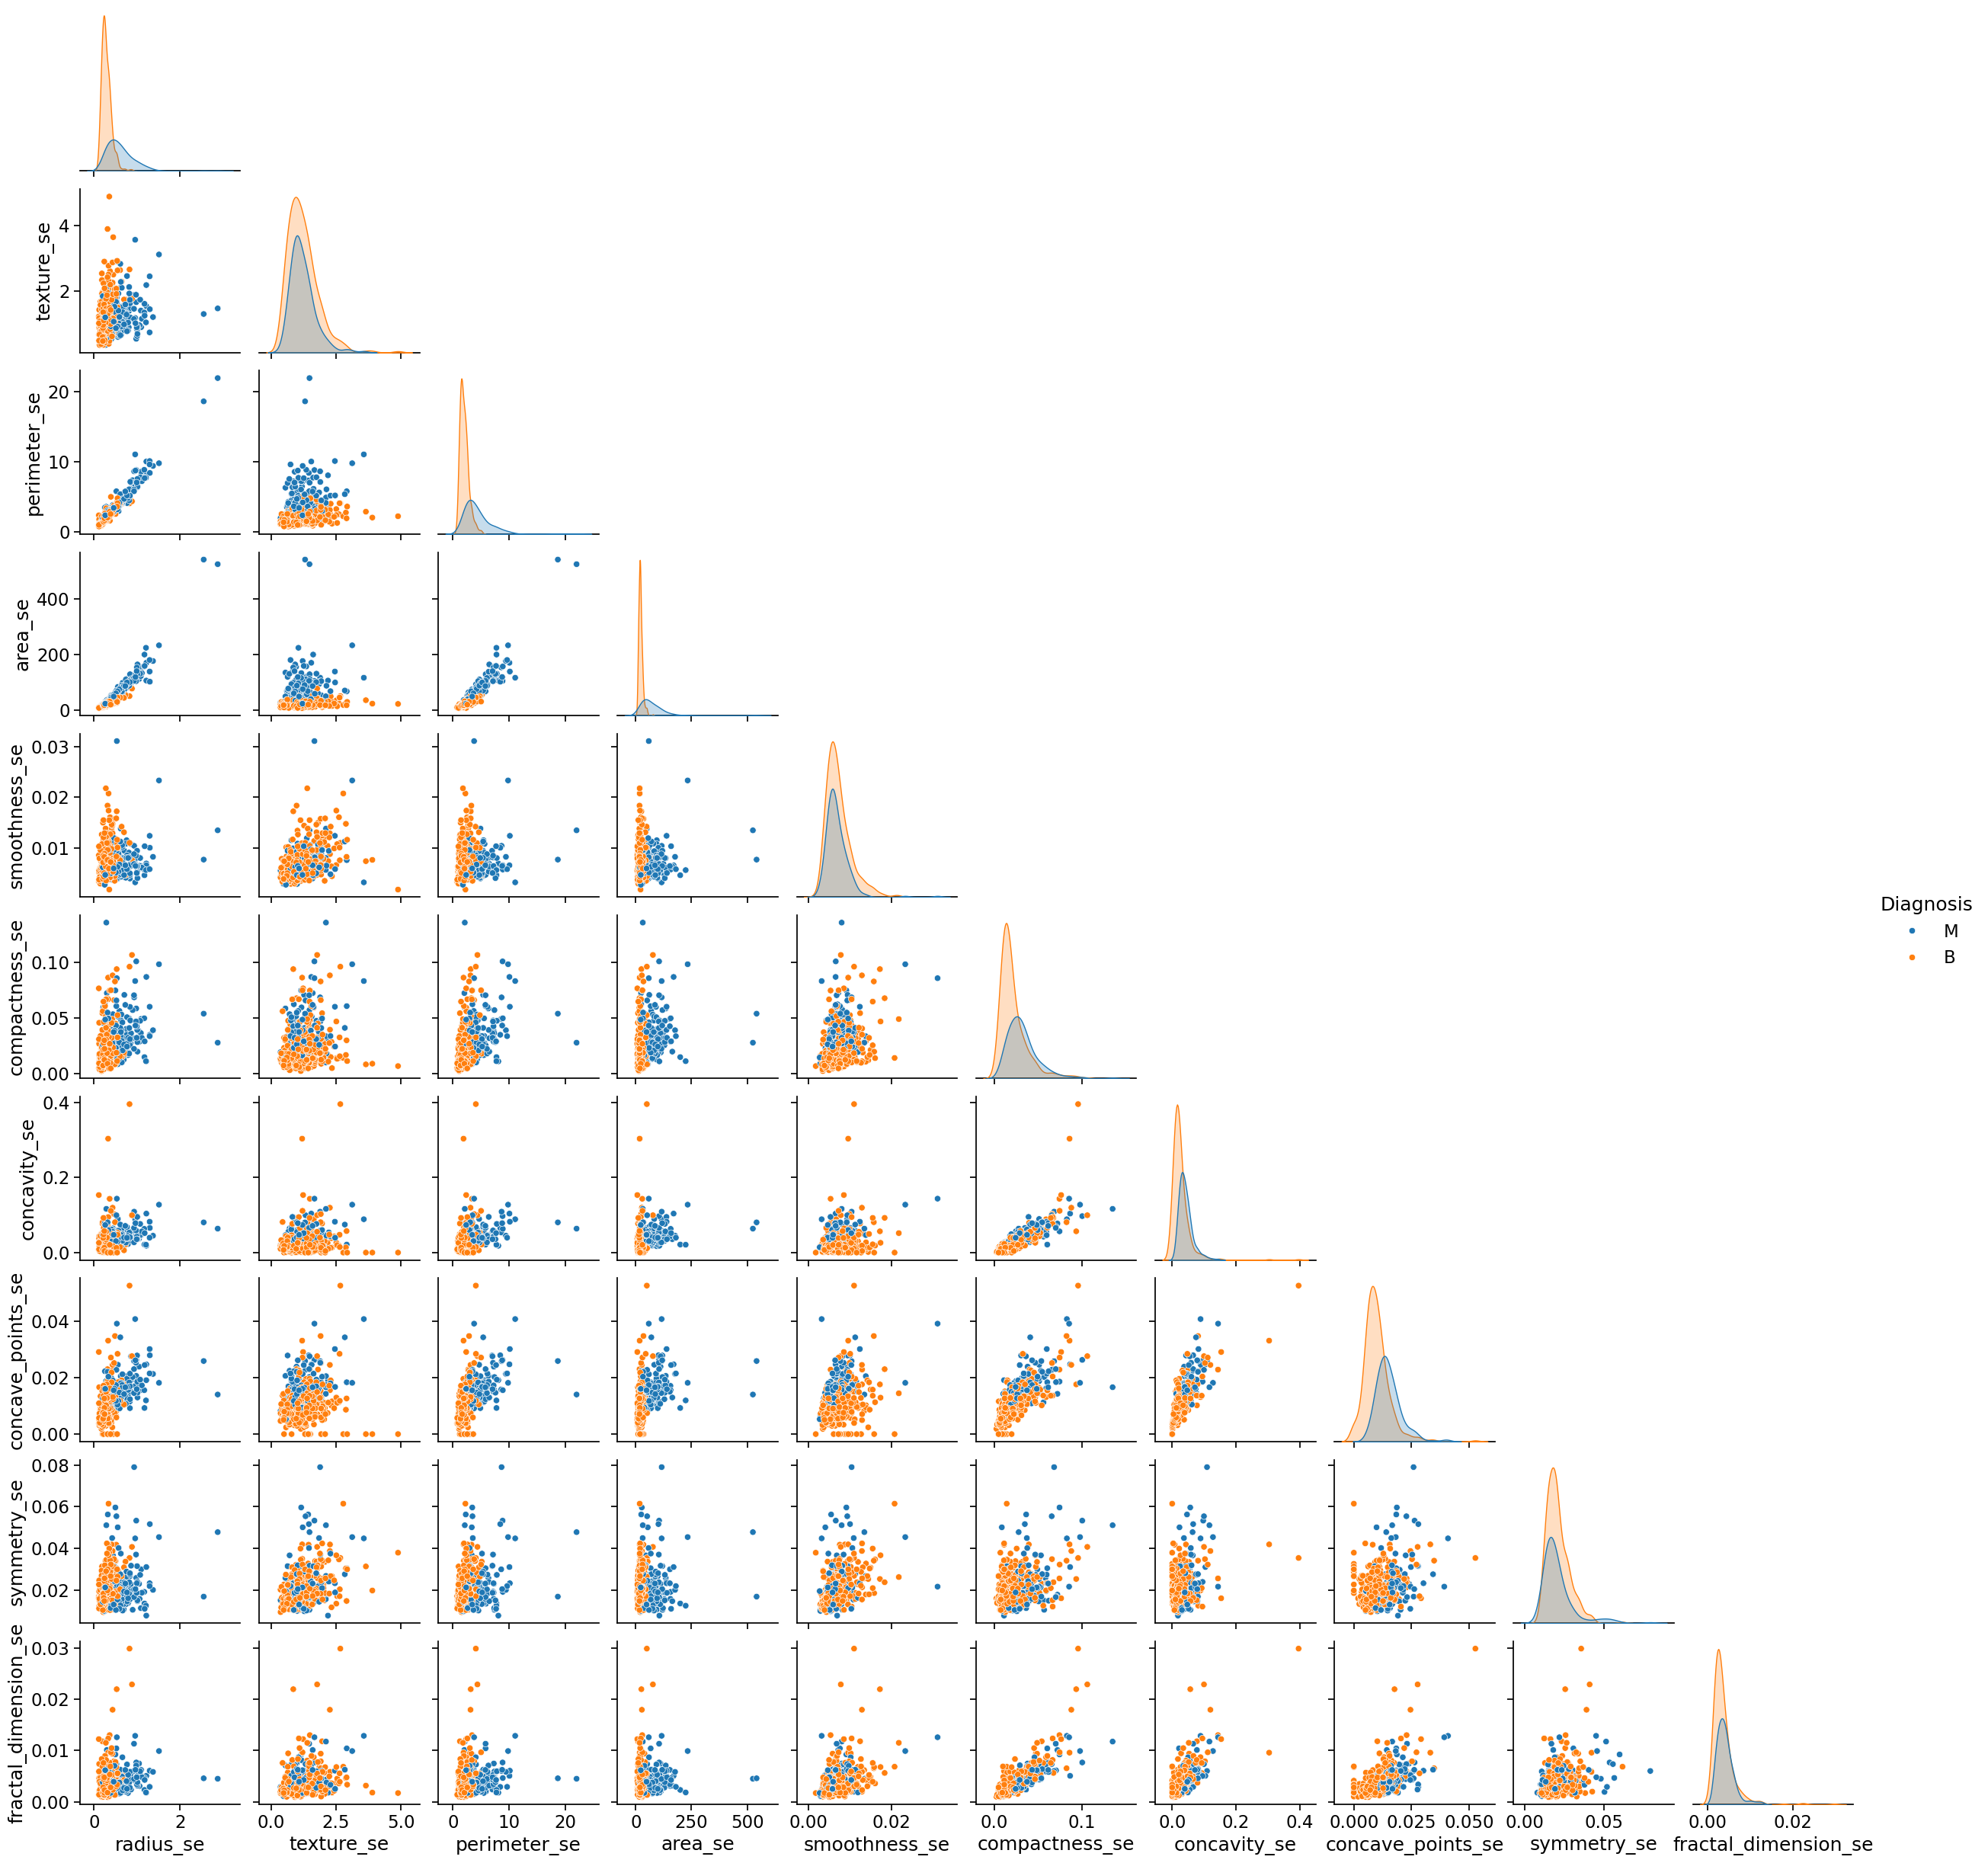

In [72]:
# Density and scatter plot by Label of Standard Error features
sns.pairplot(wdbc, hue = 'Diagnosis', vars = se_columns, corner=True) # Check for corner
plt.show()

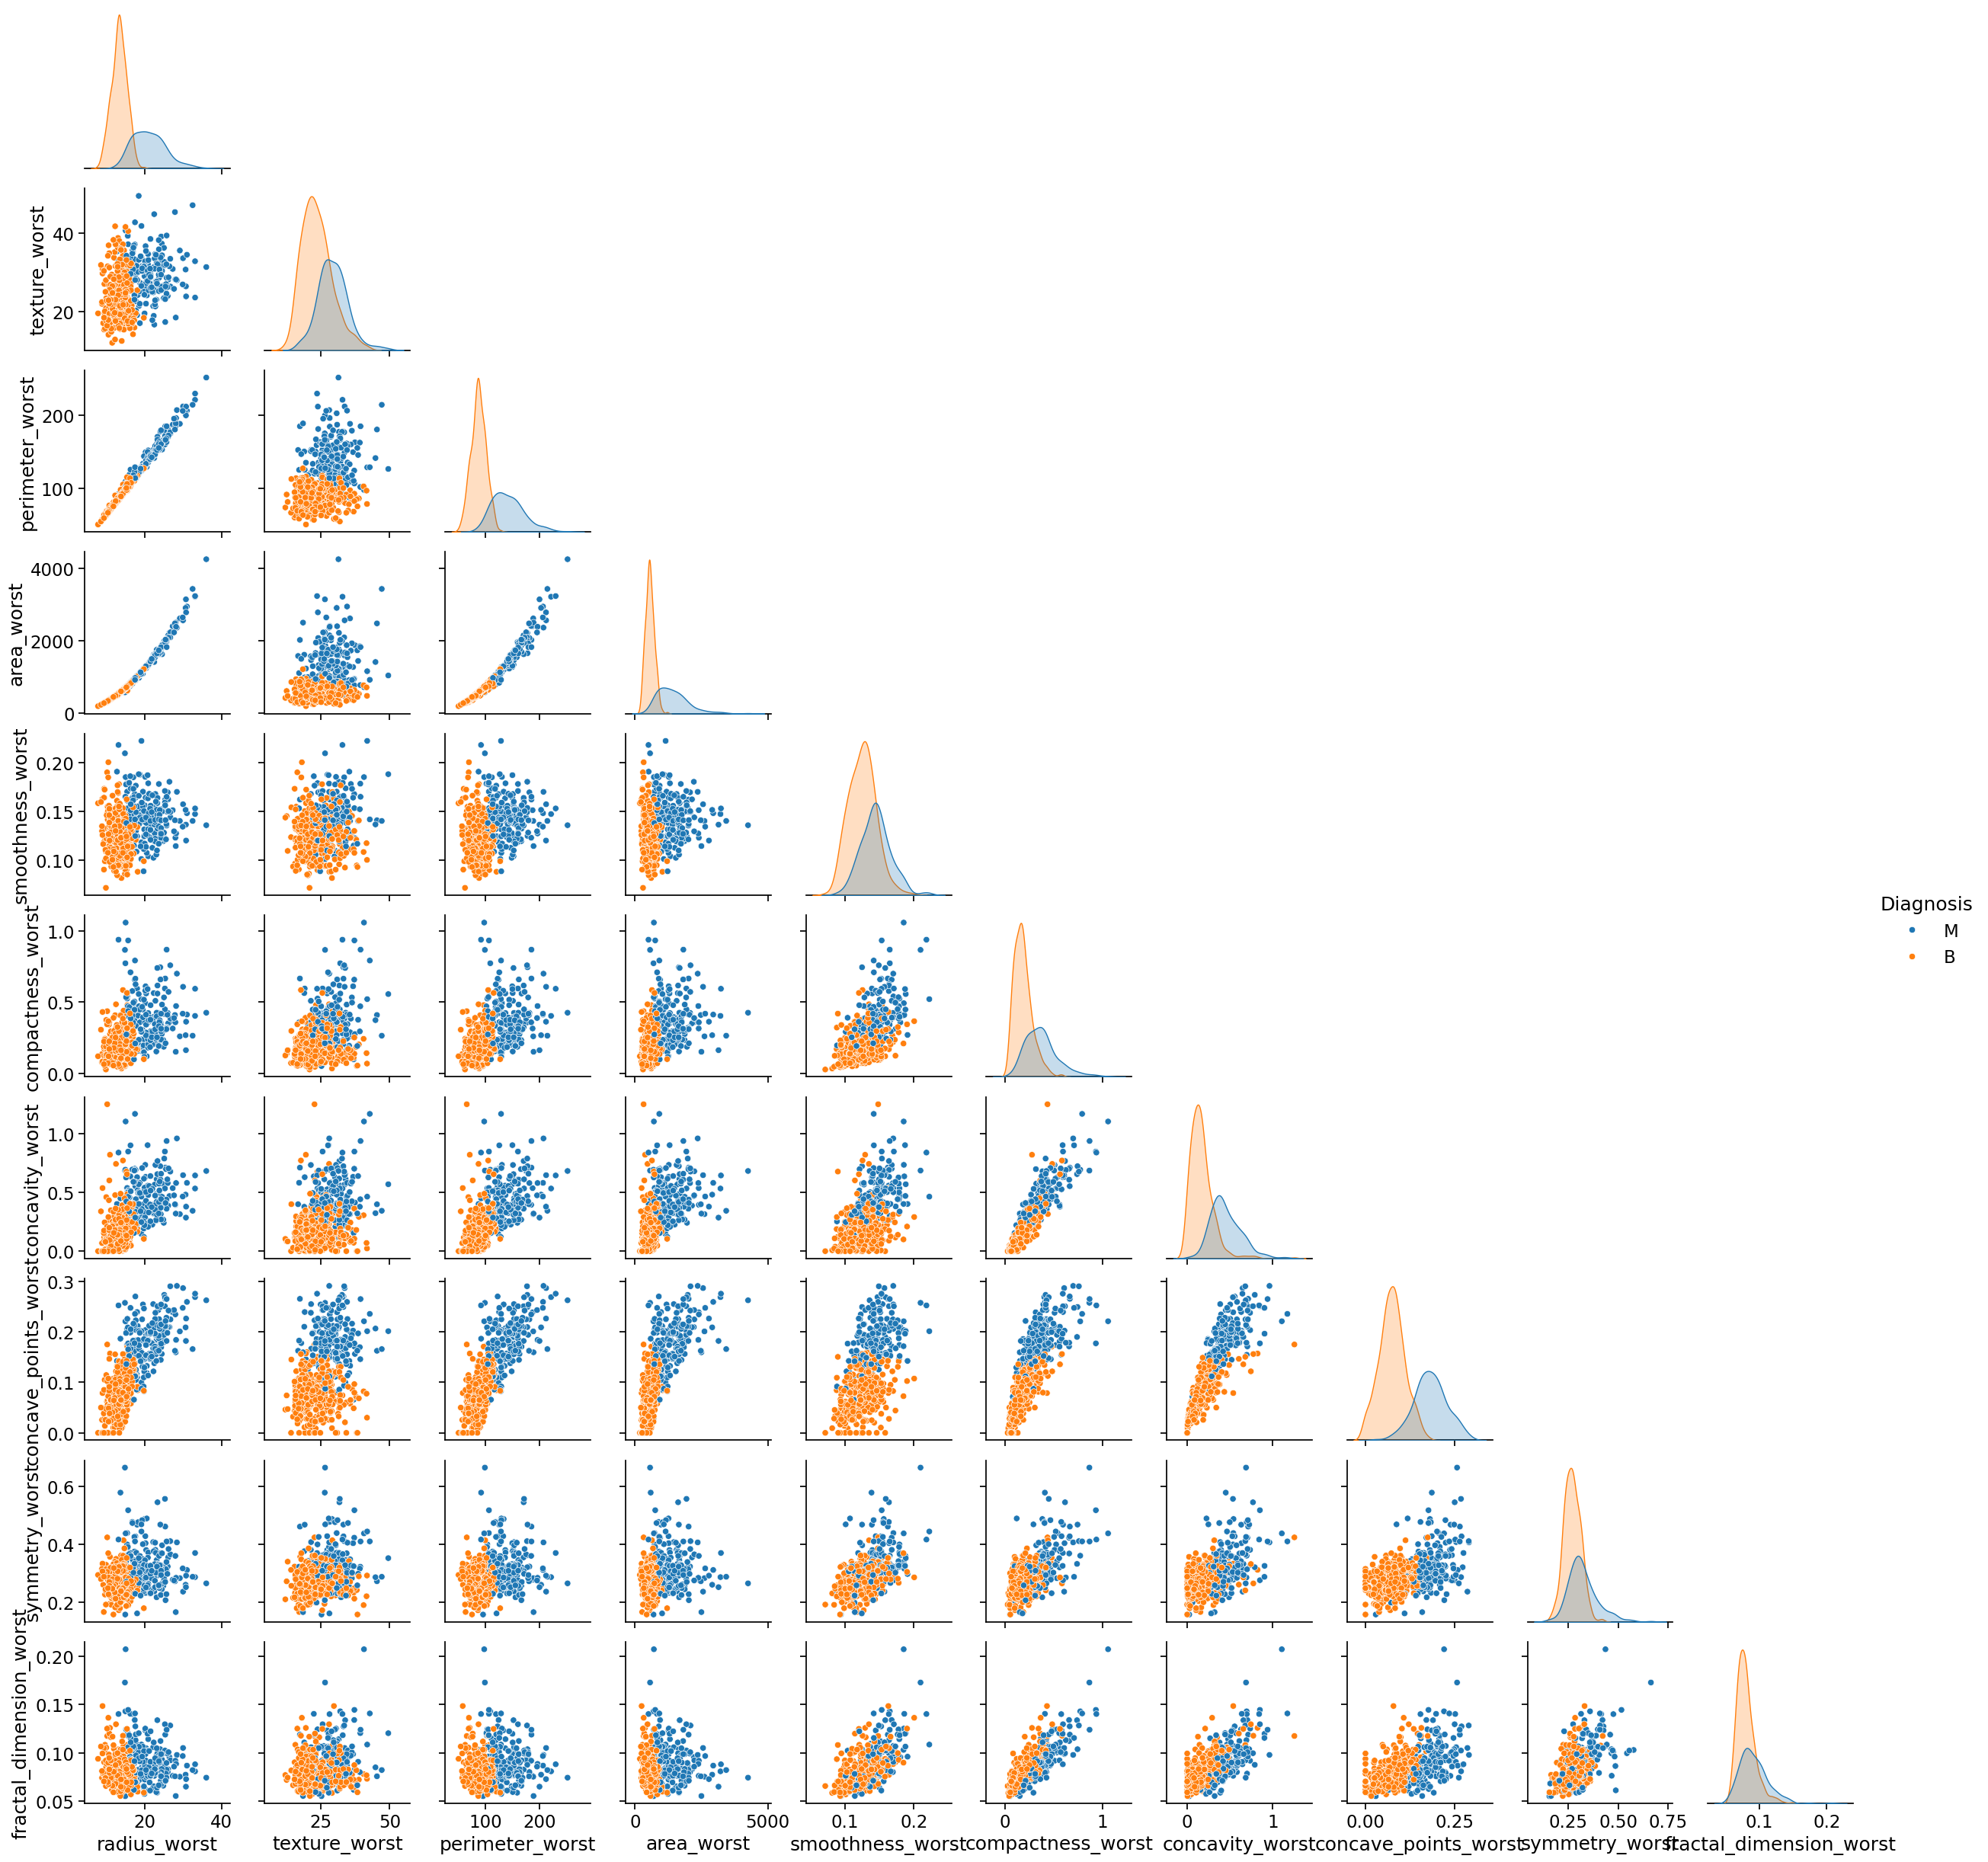

In [73]:
# Density and scatter plot by Label of Worst features
sns.pairplot(wdbc, hue = 'Diagnosis', vars = worst_columns, corner=True) # Check for corner
plt.show()

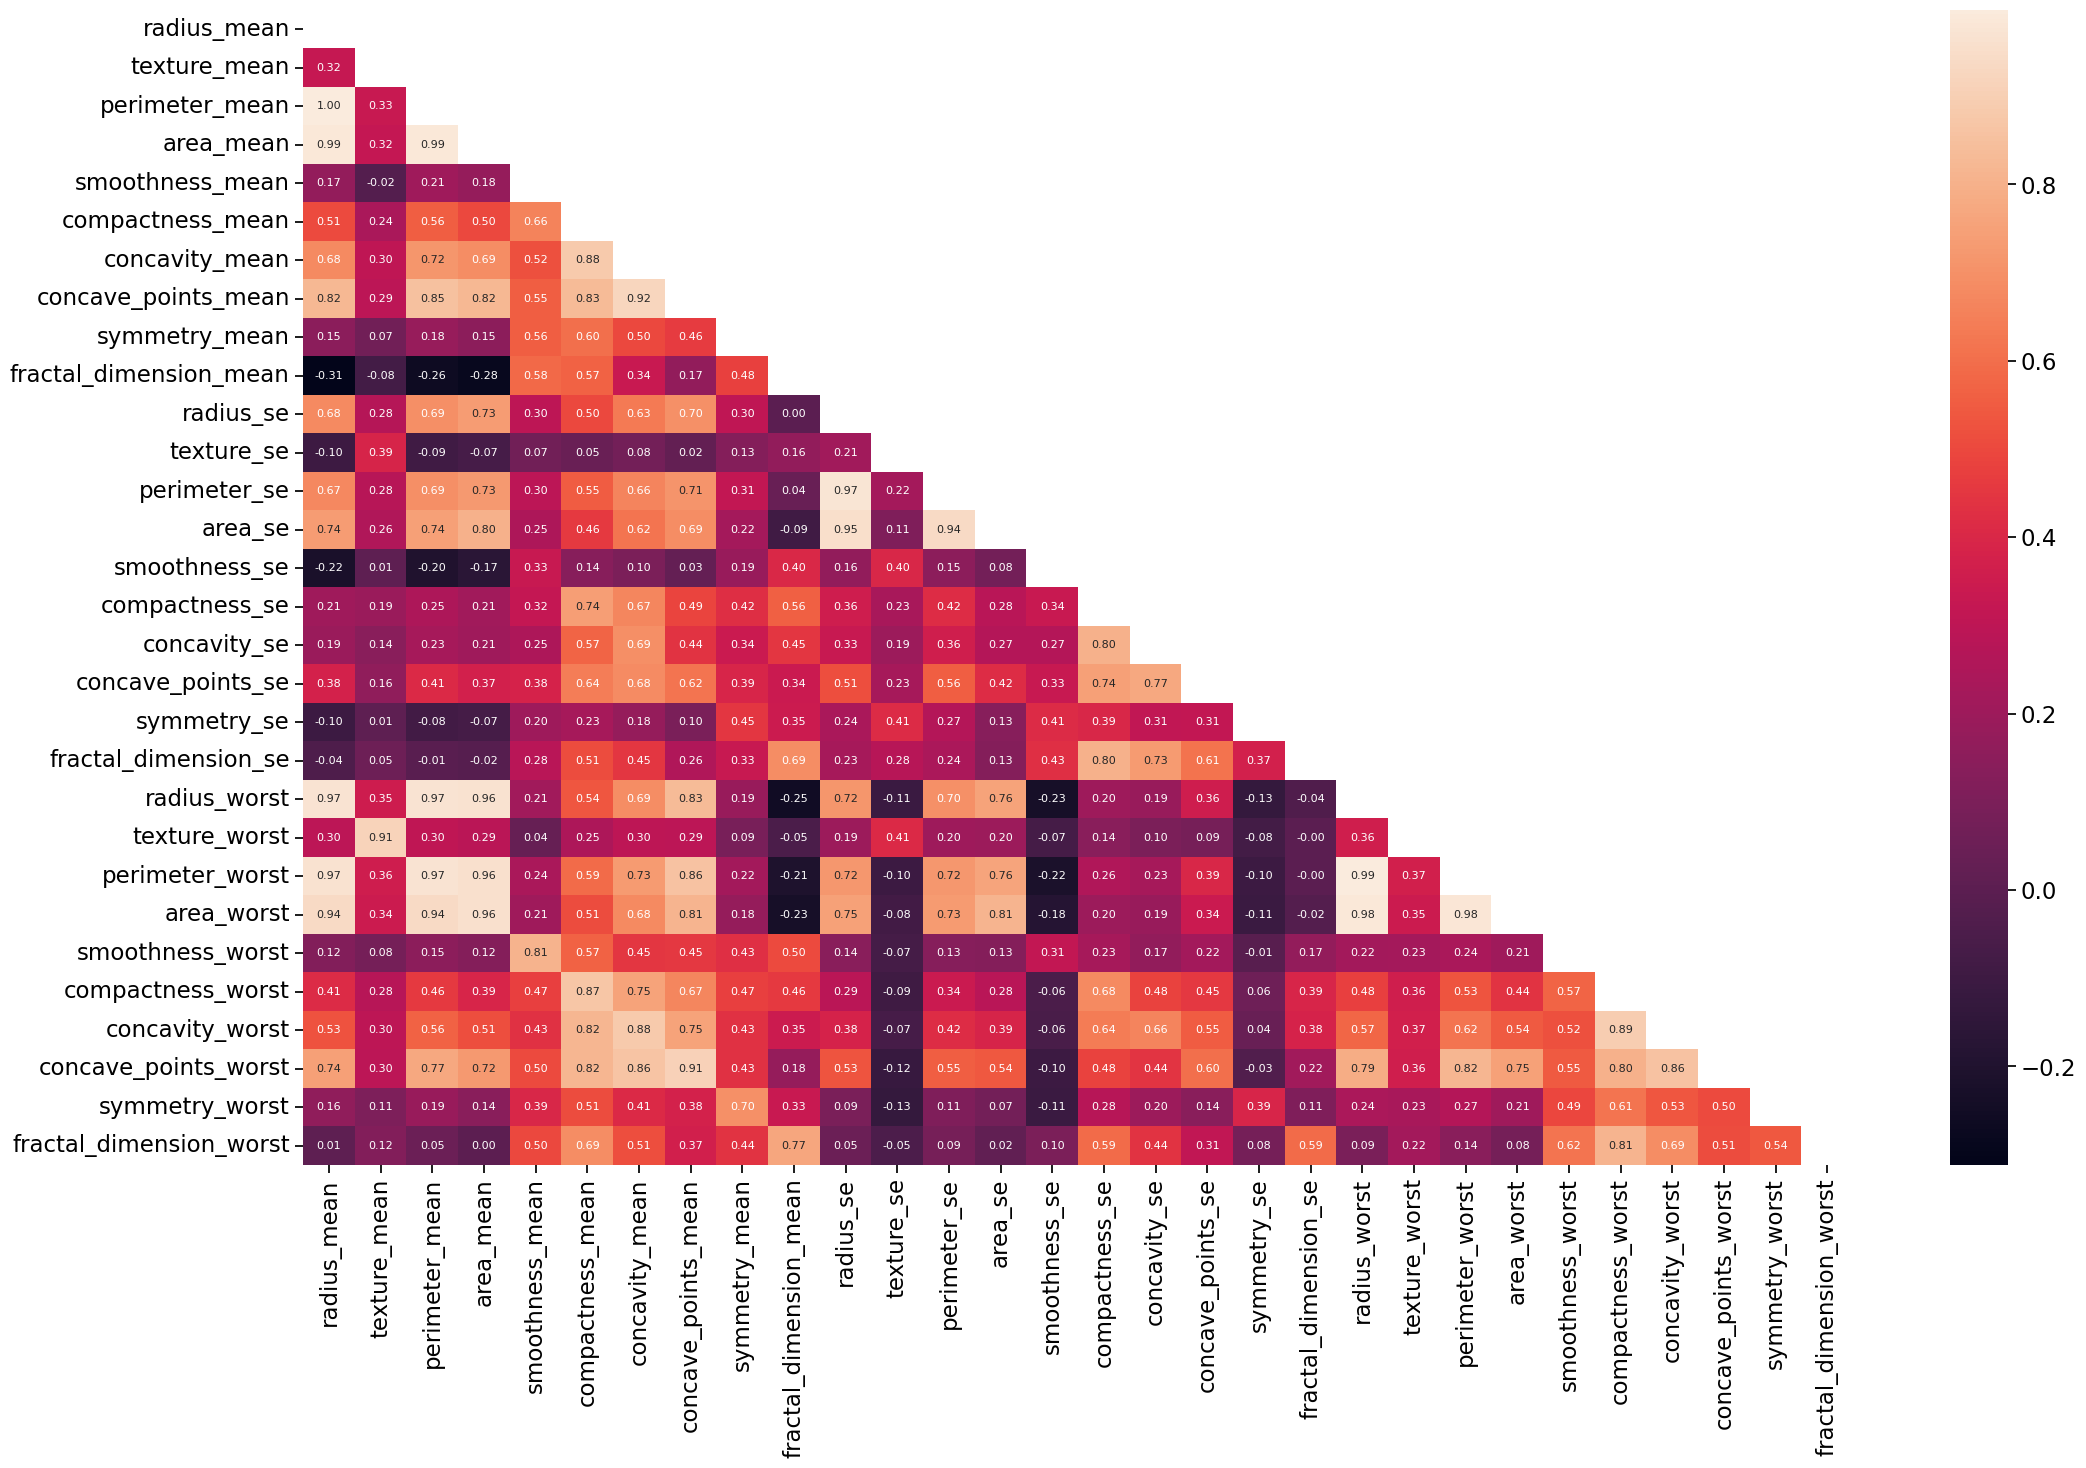

In [74]:
#Correlation Matrix
corr = wdbc[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) #Use to hide duplicated correlations
plt.figure(figsize=(25,15))
sns.heatmap(corr, annot=True, mask=mask,fmt=".2f", annot_kws={"size": 8})
plt.show()

Regarding the EDA, we have discovered several key points:
- The perimeter and area are perfectly correlated with the radius. This is sensible as the 2 features are dependent on the the radius
- The mean and the worst features are highly correlated with correlation feature ranging from 0.7 to 0.97
- The density plots of standard errors show a very similar distribution of both Malignant and Benign cases which may imply they do not have strong predictive influence
- The density plots of worst features show some different at each feature of the labels which may imply they have great nuances in predictive power
Therefore, we will drop the perimeter and area features along with the Standard Error features.

In [75]:
wdbc = wdbc.drop(columns=[col for col in wdbc.columns if 'area' in col or 'perimeter' in col], errors = 'ignore')
mean_columns = wdbc.columns[wdbc.columns.str.contains('mean')]
se_columns = wdbc.columns[wdbc.columns.str.contains('se')]
worst_columns = wdbc.columns[wdbc.columns.str.contains('worst')]
wdbc_temp= wdbc.drop(columns=se_columns)

#### 1.2.4. Data Preprocessing
<a id=preprorcessing_1></a>

As found in the previous section, the majority of the dataset is benign cases. Therefore, the splitting train and test process should be stratified preserve the distribution of classes. The approach mimic the proportionate of the dataset which may represents the imbalanced reality of the problems. Additionally, stratify ensures that the evaluaion is less likely to be biased or misled due to the remain proportionate. Hence, stratify approach set a strong foundation for a robust model.

In addition, we implement StandardScaler in the Pipeline to standardise the features on similar scale. Features varying on different scale potentially restraint the performance of the algorithm.

In [76]:
X = wdbc_temp.drop(columns='Diagnosis') #Feature columns
y = wdbc_temp['Diagnosis'].map({"M": 1, "B": 0}) #Target column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42, stratify=y)

# Pipeline for preprocessing
preprocessing = Pipeline([
    ("standardize", StandardScaler())
    ])

#### 1.2.5. Model Fitting
<a id=modelfitting_1></a>

In [77]:
# Function to calculate metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 5),
        "Precision": round(precision_score(y_true, y_pred), 5),
        "Recall": round(recall_score(y_true, y_pred), 5),
        "F1_score": round(f1_score(y_true, y_pred), 5)
    }

##### 1.2.5.1. Logistic Regression
<a id=logreg_1></a>

In [78]:
# Logisitc Regression pipeline
logreg_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
    ])

#Fitting the model and measuring time
start = timer()
logreg_pipeline.fit(X_train, y_train)
end = timer()
logreg_time = end - start

# Making predictions and calculating metrics
y_pred_logreg = logreg_pipeline.predict(X_test)
result_lg = pd.DataFrame(get_metrics(y_test, y_pred_logreg, "Logistic Regression"), index=[0])
result_lg['Training Time(s)'] = logreg_time

##### 1.2.5.2. Random Forest
<a id=randomforest_1></a>

In [79]:
# Random Forest Pipeline
randomforest_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("randomforest", RandomForestClassifier(n_estimators=100, random_state=42))
    ])

#Fitting the model and measuring time
start = timer()
randomforest_pipeline.fit(X_train, y_train)
end = timer()
rf_time = end - start

# Making predictions and calculating metrics
y_pred_randomforest = randomforest_pipeline.predict(X_test)
result_rf = pd.DataFrame(get_metrics(y_test, y_pred_randomforest, "Random Forest"), index=[0])
result_rf['Training Time(s)'] = rf_time

##### 1.2.5.3. Support Vector Machine
<a id=svc_1></a>

In [80]:
# SVM Pipeline
svc_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svc", SVC(random_state=42, probability=True))
])

#Fitting the model and measuring time
start = timer()
svc_pipeline.fit(X_train, y_train)
end = timer()
svc_time = end - start

# Making predictions and calculating metrics
y_pred_svc = svc_pipeline.predict(X_test)
result_svc = pd.DataFrame(get_metrics(y_test, y_pred_svc, "SVC"), index=[0])
result_svc['Training Time(s)'] = svc_time

##### 1.2.5.4. Voting Classifier
<a id=votingclassifier_1></a>

In [81]:
# Voting Classifier Pipeline
voting_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("voting", VotingClassifier(estimators=[
        ("logreg", LogisticRegression(max_iter=1000, random_state=42)),
        ("randomforest", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("svc", SVC(random_state=42, probability=True))
    ], voting='soft', n_jobs=-1))
])

#Fitting the model and measuring time
start = timer()
voting_pipeline.fit(X_train, y_train)
end = timer()
vc_time = end - start

# Making predictions and calculating metrics
y_pred_voting = voting_pipeline.predict(X_test)
result_vc = pd.DataFrame(get_metrics(y_test, y_pred_voting, "VotingClassifier"), index=[0])
result_vc['Training Time(s)'] = vc_time

### 1.3. Result
<a id=result_1></a>

In [82]:
def plot_conf_matrix(y_test, y_pred, model_name, ax):
    class_names = ['B', 'M']
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu", fmt='g', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('Actual label')
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names, rotation=0)

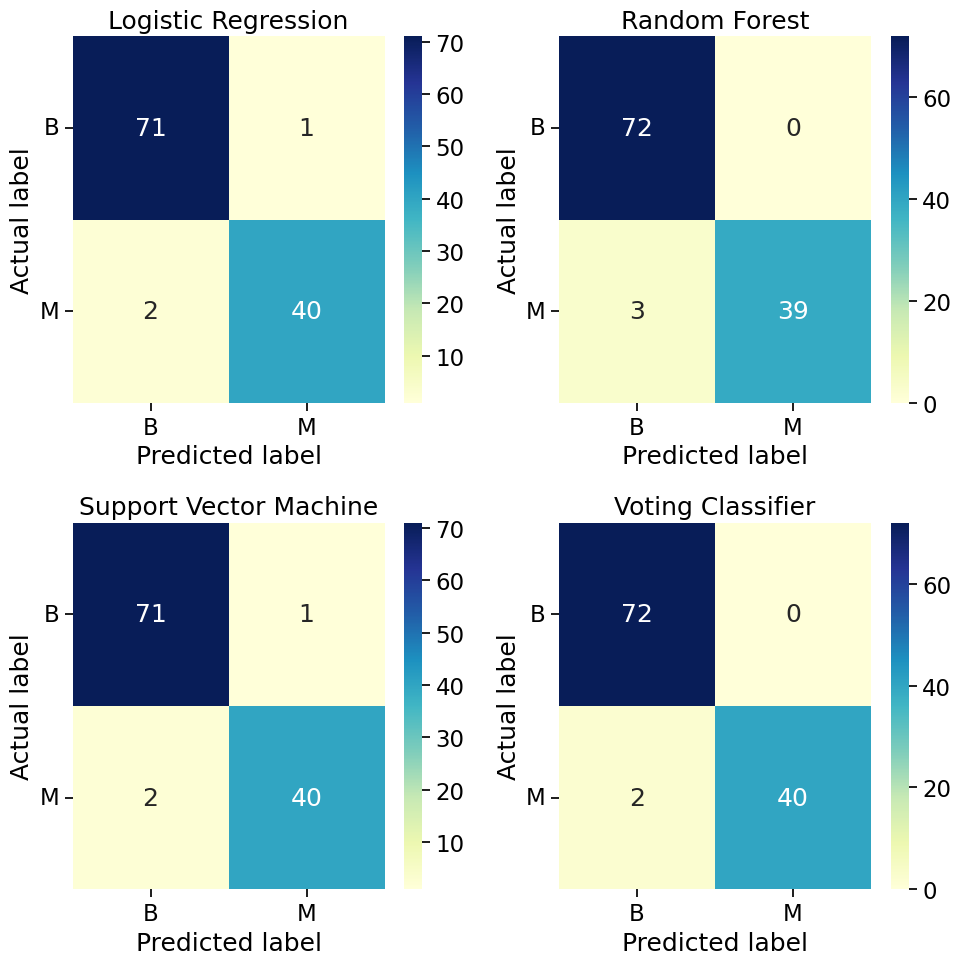

In [83]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten() # Flatten the 2x2 array into a 1D array

plot_conf_matrix(y_test, y_pred_logreg, "Logistic Regression", ax=axs[0])
plot_conf_matrix(y_test, y_pred_randomforest, "Random Forest", ax=axs[1])
plot_conf_matrix(y_test, y_pred_svc, "Support Vector Machine", ax=axs[2])
plot_conf_matrix(y_test, y_pred_voting, "Voting Classifier", ax=axs[3])

plt.tight_layout()
plt.show()


In [84]:
result_df = pd.concat([result_lg, result_rf, result_svc, result_vc], ignore_index=True)
result_df

,Model,Accuracy,Precision,Recall,F1_score,Training Time(s)
0,Logistic Regression,0.97368,0.97561,0.95238,0.96386,0.016056
1,Random Forest,0.97368,1.00000,0.92857,0.96296,0.256103
2,SVC,0.97368,0.97561,0.95238,0.96386,0.019869
3,VotingClassifier,0.98246,1.00000,0.95238,0.97561,2.774843


In [85]:
# Extract the fitted preprocessing and voting components
preprocessor = voting_pipeline.named_steps["preprocessing"]
voting_clf = voting_pipeline.named_steps["voting"]

# ransform the test data using the preprocessor
X_test_transformed = preprocessor.transform(X_test)

#Get the fitted individual models from the voting classifier
fitted_estimators = voting_clf.named_estimators_  # dictionary: name → model

# Predict probabilities and build a DataFrame
proba_df = pd.DataFrame()

for name, model in fitted_estimators.items():
    probs = model.predict_proba(X_test_transformed)
    proba_df[f"{name}_prob"] = probs[:, 1]

# Add true labels and voting predictions
proba_df["True Label"] = y_test.reset_index(drop=True)
proba_df["Voting Predicted Label"] = y_pred_voting
proba_df[(proba_df['True Label']!= proba_df['Voting Predicted Label'])|
         (round(proba_df['logreg_prob'],0) !=proba_df['Voting Predicted Label'])|
         (round(proba_df['randomforest_prob'],0) !=proba_df['Voting Predicted Label'])|
         (round(proba_df['svc_prob'],0) !=proba_df['Voting Predicted Label'])
         ]

,logreg_prob,randomforest_prob,svc_prob,True Label,Voting Predicted Label
4,0.517653,0.11,0.090492,0,0
16,0.057228,0.16,0.011637,1,0
18,0.276485,0.33,0.601482,0,0
24,0.777496,0.24,0.912053,1,1
42,0.775708,0.38,0.888238,1,1
112,0.358188,0.54,0.321110,1,0


In general, the Voting Classifier inherits the quality features of the parent models and outperforms them as expected. The precision of Voting Classifier is 100% similar to the Random Forest, while maitaining similar high recall of 95.23% like Logistic Regression and Support Vector Machine. Logistic Regression and Support Vector Machine share identical predicting performance in validation set. Random Forest is slightly better than the two in indicating Benign patients, though it is worse slightly worse as recognising Malignant patient which can be costly, regarding the fact that cancer is a malicious disease. Since, the 3 feeding models have the same accuracy, F1-score of Random Forest is slightly lower due to a bigger gap of Precision and Recall.

Regarding the approach implication, Voting Classifier demonstrates improvement in the overall performances. By combining the knowledge multiple models, the final model achieves better generalisation and robustness, avoiding overfitiing. The implementation of Soft voting strategy allows Voting Classifier to be more flexibility. Taking patient#4 as instance, while Logistic Regression model predicts the patient to be malignant, however, the model is uncertain with low probability while the two remaining models are quite certain with roughly 90% the patient is benign. Hence, the final prediction is averagely below 50% threshold, concluding the patient is benign which is accurate.

Although the business can be benefitted from a stronger and more robust model from applying ensemble learning method. There are still some drawnbacks in using the model. Training and making prediction can be significantly slower since instead of fitting and predicting with a singular model, the overall operation is depenedent on the operations of all the integrated models. Therefore, in case of the increasing in number of features or training instances, the time and cost are significantly impacted, especially in case of algorithms that do not scale well with large dataset like Support Vector Machine. Another notable drawback is the interpretability. While individual such as Logistic Regression provide vivid intuitions of the problem where the stakeholders can make action or decision to drive the outcome,  the ending product of ensemble learning is simply a prediction with little information how the features interact to produce the output. Addtionally, Voting Classifier performance is dependent on the performance of input models. If the majority of the input models are not compatible for the problem, the model will produce poorly ending result. The process, hence, is required extra effort to select the suitable models to ensure the ensemble achieve high performance.


## 2. Labeled Faces in the Wild
<a id=part_2></a>

While sufficient number of features can provide quality information for the ML algorithm in comprehending the problem, large number of features involved can significantly slowdown the training process and introducing bias to the model making it overfit. The issue is often referred to as the curse of dimensionality. In this section, we will tackle the faces recognition problem which involves thousand of features with a dimensionality reduction approach. The goal of the method is to reduce the complication of training process significantly while remaining the majority of the information.

To evaluate the performance of the approach, we will use the face image dataset obtained from [Labeled Faces in the Wild (LFW)](http://vis-www.cs.umass.edu/lfw/) dataset.

### 2.1. Methodology
<a id=methodology_2></a>

Principal Component Analysis (PCA) is a powerful dimensionality reduction algorithm. The main idea of the method is that the algorithm projects the data onto the closest lower-dimensional hyperplane. PCA uses Singular Value Decomposition to identify vector $V$ containing all the pricipal components, then project training set down to lower dimensonality d using the following formula:
$$
X_{d\text{-proj}} = XW_d
$$
Where $X$ is the matrix of training set, and $W_d$ is defined as the matrix containing the first d columns of $V$.

However, PCA is a simply a method to reduce the dimensionality of the training set. In order to perform face recognition task, we use Random Forest to perform classification. Random Forest is a powerful ensemble learning algorithm that can perform classification task. By combining multiple trained decision trees, the final model can achieve higher accuracy while avoiding overfitting the trained data.

In order to evaluate the application of PCA, we will compare the output result of an individual Random Forest with a Random Forest PCA-integrated.

### 2.2. Implementation
<a id=implementation_2></a>

#### 2.2.1. Import Libraries
<a id=import_2></a>

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, recall_score, precision_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from scipy.stats import randint
from timeit import default_timer as timer

#### 2.2.2. Import Data
<a id=import_data_2></a>

In [87]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.5)
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
X_images = lfw_people.images
n_features = X.shape[1]
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

#### 2.2.3. Exploratory Analysis
<a id=eda_2></a>

In [88]:
print(f'Number of instances: {n_samples}')
print(f'Height: {h} and Width: {w}')
print(f'Number of features: {n_features}')
print(f'Feature example: {X[0]}')
print(f'Number of classes: {n_classes}')
print(target_names)

Number of instances: 1288
Height: 62 and Width: 47
Number of features: 2914
Feature example: [0.9973857  0.9973857  0.99607843 ... 0.38431373 0.3869281  0.3803922 ]
Number of classes: 7
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


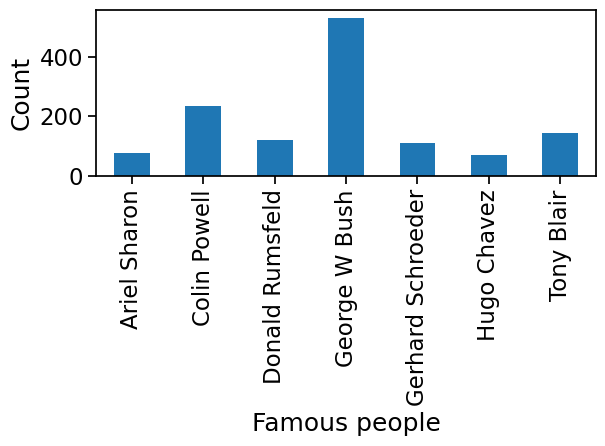

In [89]:
y_series = pd.Series(y).map(lambda i: target_names[i])
y_series.value_counts().sort_index().plot.bar()
plt.tick_params(axis='x', labelrotation=90)
plt.xlabel('Famous people')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The dataset consists of 1288 instances where each instance corresponds to the grayscale image of a face. The dataset includes both the image data and the associated name of the person.

The features are pixel intensity values of the face images flattend into 1D array, where each element represents a graysacle value of a pixel. Each image consists of 2914 features (62x47 pixels).

The target refers to the person's identity associated with each image. In this case, the dataset consists of images of 7 well-known public figure:
- Ariel Sharon
- Colin Powell
- Donald Rumsfeld
- George W. Bush
- Gerhard Schroeder
- Hugo Chavez
- Tony Blair

However, the dataset is not uniformly distributed where images of former president George W.Bush proprotionate the majority of the dataset. Hence, with a large gap between classes, stratify splitting of train and validation set is signified to ensure the generalisation of the model.

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

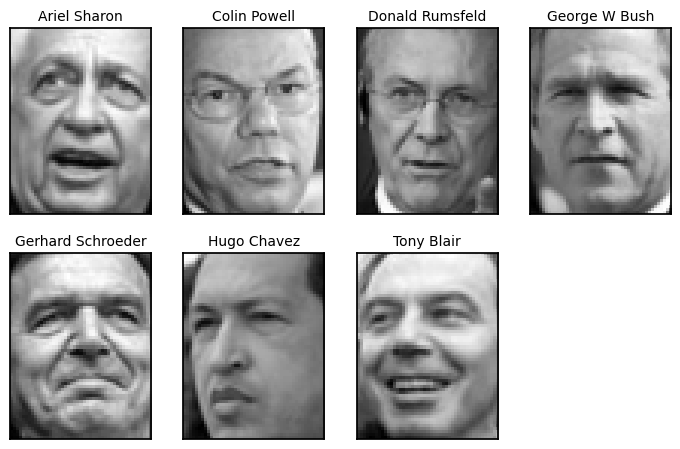

In [91]:
# Get unique class labels
unique_labels = np.unique(y)

# Sample one random image per class
sample_indices = [np.random.choice(np.where(y == label)[0]) for label in unique_labels]
sample_images = X_images[sample_indices]
sample_names = [target_names[label] for label in unique_labels]

# Generate the plot
def plot_faces(images, titles, h, w, cols=5):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(1.8 * cols, 2.4 * rows))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image, cmap=plt.cm.gray)
        plt.title(title, fontsize=10)
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

# Plot one random sample per person
plot_faces(sample_images, sample_names, h, w, cols=4)

#### 2.2.4. Feature Importance Analysis
<a id=featureimportance_2></a>

In [92]:
# Function to calculate metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 5),
        "Precision": round(precision_score(y_true, y_pred, average='macro'), 5),
        "Recall": round(recall_score(y_true, y_pred, average='macro'), 5),
        "F1_score": round(f1_score(y_true, y_pred, average='macro'), 5)
    }

In [109]:
random_forest = RandomForestClassifier(random_state=42, n_estimators=1000)
start = timer()
random_forest.fit(X_train, y_train)
end = timer()
randomforest_train_time = round(end - start,3)
y_pred = random_forest.predict(X_train)
result_rf_train = pd.DataFrame(get_metrics(y_train, y_pred, "Random Forest"), index=[0])
print(result_rf_train)

           Model  Accuracy  Precision  Recall  F1_score
0  Random Forest       1.0        1.0     1.0       1.0


In [94]:
y_pred_test = random_forest.predict(X_test)
result_rf = pd.DataFrame(get_metrics(y_test, y_pred_test, "Random Forest"), index=[0])
result_rf

,Model,Accuracy,Precision,Recall,F1_score
0,Random Forest,0.65504,0.84672,0.42801,0.48187


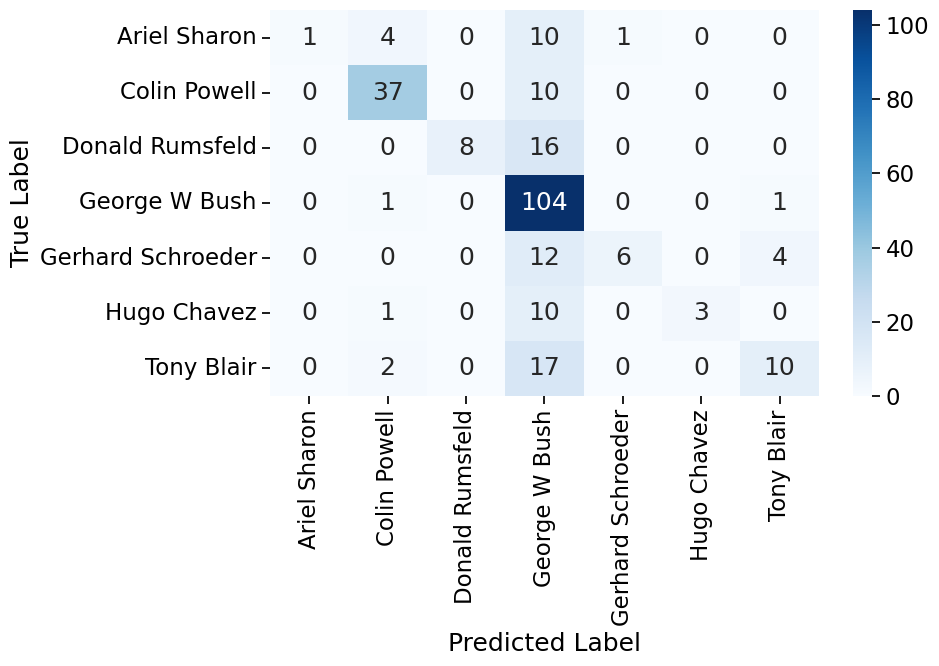

In [95]:
confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [96]:
randomforest_report = classification_report(y_test, y_pred_test, target_names = target_names)
print(randomforest_report)

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.06      0.12        16
     Colin Powell       0.82      0.79      0.80        47
  Donald Rumsfeld       1.00      0.33      0.50        24
    George W Bush       0.58      0.98      0.73       106
Gerhard Schroeder       0.86      0.27      0.41        22
      Hugo Chavez       1.00      0.21      0.35        14
       Tony Blair       0.67      0.34      0.45        29

         accuracy                           0.66       258
        macro avg       0.85      0.43      0.48       258
     weighted avg       0.75      0.66      0.61       258



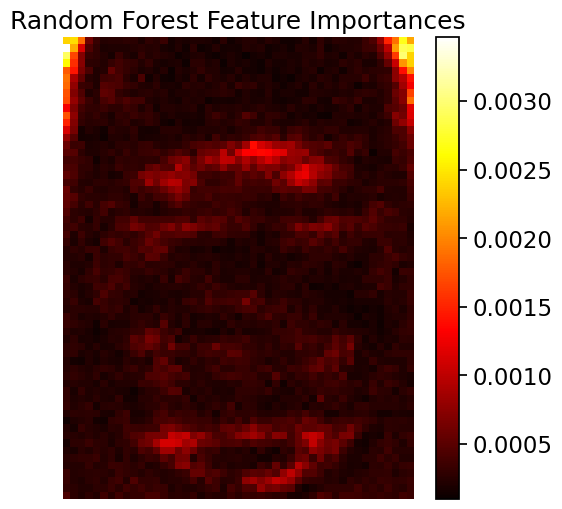

In [97]:
importances = random_forest.feature_importances_
importances_image = importances.reshape((h,w))

# Plot as a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(importances_image, cmap=plt.cm.hot)
plt.title("Random Forest Feature Importances")
plt.colorbar()
plt.axis('off')
plt.show()

The model precision is quite high, however, the recall is signifcantly lower due to the fact that the model tend to predict former US president George W. Bush since the data distribution is heavily skewed toward him.
Hence, the model have high precision for George W.Bush specificly but low recall due to wrongly classified others as him and low precision in identifying other figures.
Although Random Forest is generally not a model compatible for face recognition task, the algorithm can still realise the importance features that can guide the classification. From the generated importance features heatmap, the belows features are the most influence on identifying a person:
- Area around the chin: shape of the chin can give great information to the face shape like oval, square, etc shape
- Area around the nose: distinguish nose type like wide, big, or small one
- Area around the eyes: eyes' feature like thick or thin eyebrowns, wide or small shape also helps guide the differences recognition
- Side hairline: differentiate if a person is fully bald or not

#### 2.2.5. Principal Component Analysis (PCA)
<a id=pca></a>

As we have seen from the previous section, not every feature shares the equal amount of influence on the task. Some are highly informative while the major barely have any value. In this section, we will perform the PCA the reduce the dimensions size down to **150** features from initially 2914.

Although only roughly 5% of the total features remain, the lower-dimensionality is still able to explain 93.83% of variance. To demonstrate the retained information, we display eigenfaces of the first 10 instances. Eigenfaces are the principal components shrinked from orginal 2914 features down to 150 eigenvectors from the PCA process. The original image is projected onto the eigenvectors which although are not able to retain all the information due to lower-dimensionality but preserve the majority of the variance. Hence, the eigenfaces represent the most importance facial variations of the figures.

In [98]:
n_components = 150
pca = PCA(n_components=n_components, random_state=42)
start = timer()
X_pca = pca.fit_transform(X_train)
end = timer()
pca_transform_time = round(end - start, 3)

In [99]:
print(f"Total number of dimensions before PCAl: {n_features}")
print(f"Total number of dimensions after PCA: {X_pca.shape[1]}")
print(f"Explained variance ratio of PCA components: {sum(pca.explained_variance_ratio_):4f}")

Total number of dimensions before PCAl: 2914
Total number of dimensions after PCA: 150
Explained variance ratio of PCA components: 0.938342


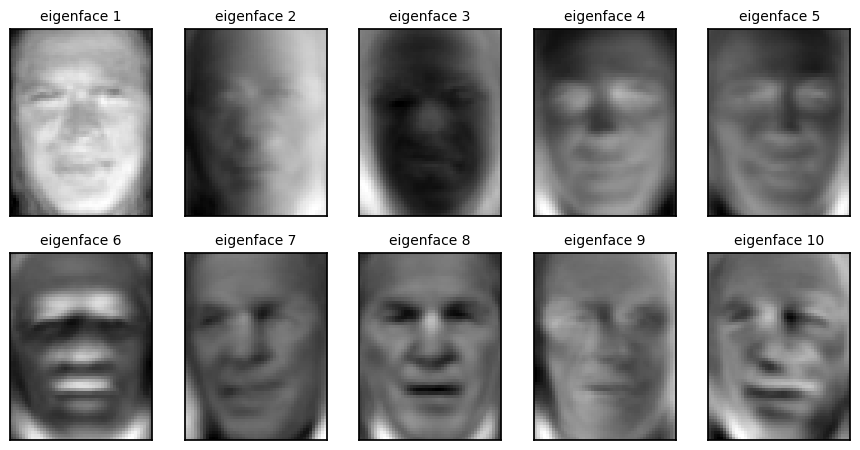

In [100]:
eigenfaces = pca.components_.reshape((n_components, h, w))
eigenface_titles = [f"eigenface {i+1}" for i in range(10)]
plot_faces(eigenfaces[:10], eigenface_titles, h, w)

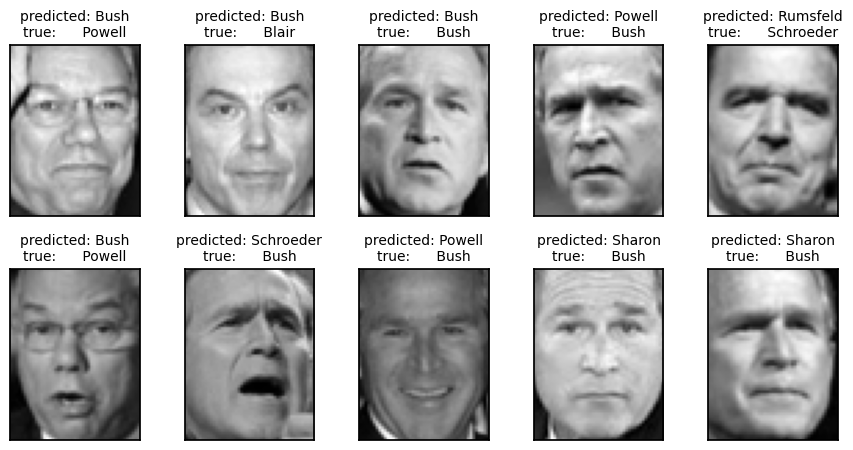

In [101]:
# Reshape X_test for display if it's flattened
X_test_images = X_test[:10].reshape((-1, h, w))

# Helper function to create prediction title
def title(y_pred, y_true, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(" ", 1)[-1]
    true_name = target_names[y_true[i]].rsplit(" ", 1)[-1]
    return f"predicted: {pred_name}\ntrue:      {true_name}"

# Generate prediction titles
prediction_titles = [title(y_pred, y_test, target_names, i) for i in range(10)]

# Plot with titles
plot_faces(X_test_images, prediction_titles, h, w)

#### 2.2.6. Random Forest PCA integrated
<a id=randomforest_pca></a>

In [110]:
# Fit the Random Forest with PCA-engineered features
randomforest_pca = RandomForestClassifier(random_state=42, n_estimators=1000)
start = timer()
randomforest_pca.fit(X_pca, y_train)
end = timer()
randomforest_pca_train_time = round(end - start, 3)
y_pred_pca = randomforest_pca.predict(pca.transform(X_test))
result_rf_pca = pd.DataFrame(get_metrics(y_test, y_pred_pca, "Random Forest PCA integrated"), index=[0])

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

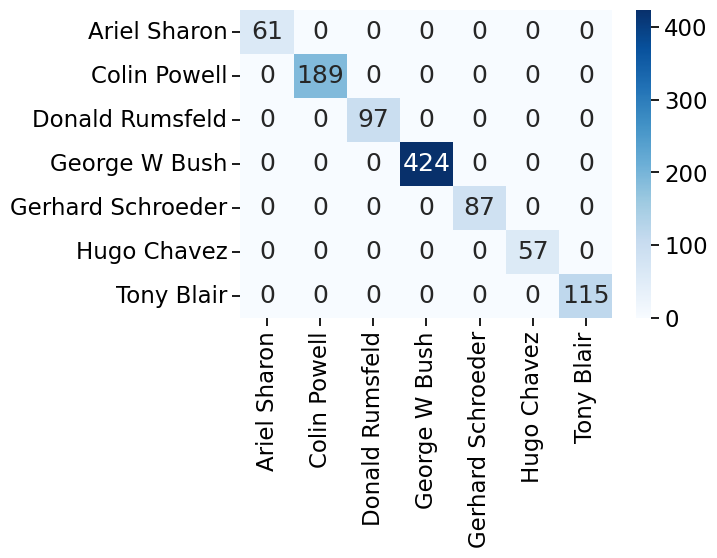

In [103]:
# Confusion Matrix for train dataset
y_pca_train = randomforest_pca.predict(X_pca)
confusion_matrix(y_train, y_pca_train)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_train, y_pca_train), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)

<Axes: >

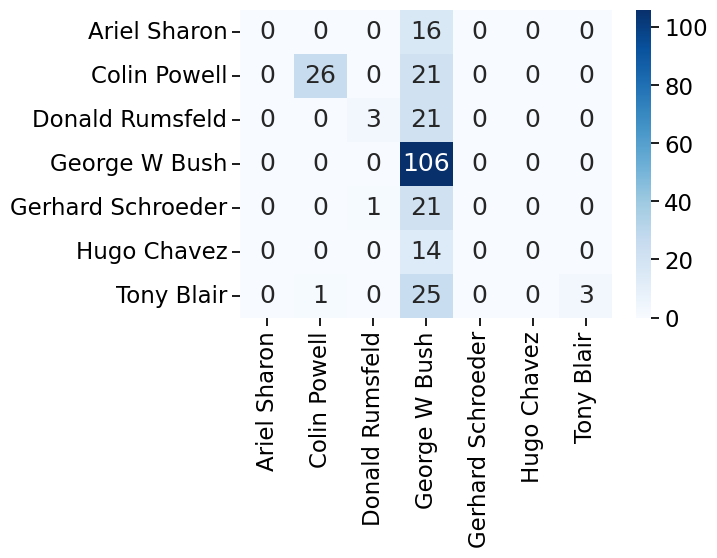

In [104]:
# Confusion matrix for test dataset
confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_pca), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)

### 2.3. Result
<a id=result_2></a>

To evaluate how well the Random Forest perform after the PCA features-engineered process, we assess and compare the models on 3 aspects:
- Performance
- Training Time
- Feature Importances Recognition

In [111]:
pca_report = classification_report(y_test, y_pred_pca, target_names = target_names, zero_division=0.0)
print("Random Forest:")
print(randomforest_report)
print("------------------------------------------------------------")
print("Random Forest PCA Integrated:")
print(pca_report)
print("-----------------------------------------------------------------------")
result_df = pd.concat([result_rf, result_rf_pca], ignore_index=True)
print(result_df)
print("-----------------------------------------------------------------------")
training_times_df = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest + PCA'],
    'PCA (s)':[0, pca_transform_time],
    'Training (s)': [randomforest_train_time, randomforest_pca_train_time]
})
training_times_df['Total (s)'] = training_times_df['PCA (s)'] + training_times_df['Training (s)']
print(training_times_df)
print(f"Training time only difference: {round(randomforest_train_time/randomforest_pca_train_time,3)}")

Random Forest:
                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.06      0.12        16
     Colin Powell       0.82      0.79      0.80        47
  Donald Rumsfeld       1.00      0.33      0.50        24
    George W Bush       0.58      0.98      0.73       106
Gerhard Schroeder       0.86      0.27      0.41        22
      Hugo Chavez       1.00      0.21      0.35        14
       Tony Blair       0.67      0.34      0.45        29

         accuracy                           0.66       258
        macro avg       0.85      0.43      0.48       258
     weighted avg       0.75      0.66      0.61       258

------------------------------------------------------------
Random Forest PCA Integrated:
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.96      0.55      0.70        47
  Donald Rumsfeld       0.75      0.12      0.21        24
    G

Regarding the performance, the PCA-integrated model is expected to not perform as well as the individual model due to the loss in information. The result, in fact, confirm the expectation as performance of the integrated model drop in all criterias comparing to the individual one. Similar to the individual Random Forest model, the PCA-integrated's predictions are skewed toward the majority classes. Though the PCA did not make any prediction for scarce classes unlike the individual model were still able to correctly classify some although very minimal. In summary, the individual Random Forest model is the better performer. However, it is notable to mention that both model is overfitting in the training process with 100% accuracy and less likely to be generalised in the test set. This can be potentially due to the fact that Random Forest lacks the ability to recognise spatial correlation where slightly twitch of feature resulted from different angle can mislead the model, making it not a strong face recognition model.

Although the PCA-integrated model does not perform as well as the non-features-engineered model, PCA model outperform the full features model in total training time by far. The Random Forest takes approximately 46 seconds to fit 2914 features and train while it only takes roughly 15 seconds to train the model with same hyperparameters but with only 150 features. By reducing the dimensionality by 95%, the PCA shortened the training time by more than three times. The reduction can be explained based on the fact that Random Forest is an ensemble of Decision Trees where the training computational complexity is depending on the number of features: $O(n \times m \log_2 m)$

Additionally, since in both cases, we do not identify the *max_features* hyperparameter which is set at 'sqrt' equivalent to squared-root number of features: $\sqrt{n}$. Hence, the difference is expected to be roughly: $\frac{\sqrt{2914}}{\sqrt{150}} \approx 4.4$ times difference.

In [106]:
# Project PCA importances back to original feature space
original_feature_importance = np.abs(pca.components_.T @ randomforest_pca.feature_importances_)
original_feature_importance /= original_feature_importance.sum()

# Reshape to original image shape
importances_image_pca = original_feature_importance.reshape((h, w))

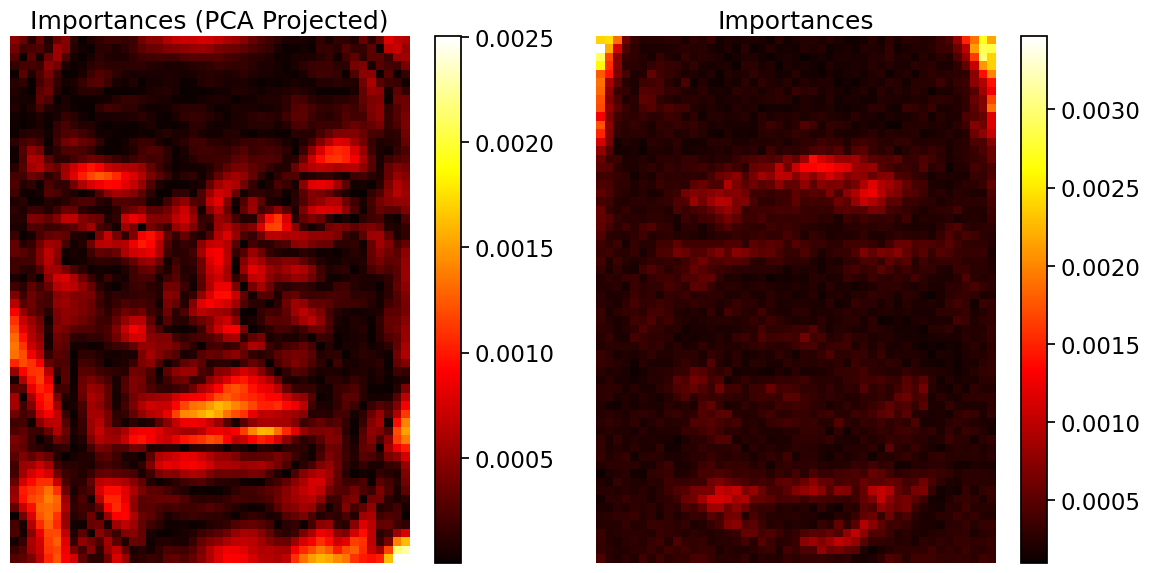

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# PCA-Integrated RF Importances
im0 = ax[0].imshow(importances_image_pca, cmap=plt.cm.hot)
ax[0].set_title("Importances (PCA Projected)")
ax[0].axis('off')
fig.colorbar(im0, ax=ax[0])

# Standard RF Importances
im1 = ax[1].imshow(importances_image, cmap=plt.cm.hot)
ax[1].set_title("Importances")
ax[1].axis('off')
fig.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

Regarding the feature importances, majority of the pixels remain their importances such area around the eyes, nose, and chin. PCA integrated model considers some additional pixels more importantly than the individual such as area on the bottom left and right of the image. The areas indicate the outer shape forming the face which is sensible as people can have different face shape like square, oval, wide etc. However, although the individual model regards the side hair line as those most importances features to differentiate fully bald or not figure, the feature-engineered model does not weight those pixels as any important.

In summary, the PCA-features retain quite similar variances as the original features with few differences. This is expectedly aligned with the fact that although majority of dimensions are reduced, 93% of the variances are still maintained post PCA-process.

## Conclusion
<a id=conclusion></a>

In summary, we have demonstrated the application of machine learning in healthcare domain in the first section by using ensemble learning. Although the individual models already achieve high precision and recall in the validation test, the voting classifier is still able to squeeze out more improvement by aggregating the models' prediction. It is, however, notable to mention that though ensemble learning methods can be implemented to improve overall performance, there are still considerable drawbacks in the scalability due to long training time and the implication due to the lack of intuition.

On the other hand, in the second section, we demonstrate a dimensionality-reduction approach to enhance the model scalability. We perform a classification task using Random Forest for face recognition problems. Although the model is not generalised well for the problem, by implementing PCA features-transformation, the model's training time decreases impressively while maintaining the majority of the variance. We highly suggest applying a more compatible algorithm for this specific task such as Convolutional Neural Network in future study.

In conclusion, while ensemble approach can significantly improve the performance of the prediction model, other aspects should also be considered when implementing. At the same time, while sacrificing minority of the performance because of information loss, PCA can greatly improve the model training time while retaining most importances intel, allowing model to scale better in high dimensional problems.